In [1]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [2]:
# import the cleaned dataset 
df = pd.read_csv("../data/interim/clean_data.csv")
df

,CASENUM,VEH_NO,MAKE,MAKENAME,MOD_YEAR,MODEL,BODY_TYP,BODY_TYPNAME,VPICBODYCLASS,VPICBODYCLASSNAME,...,WEATHER,WEATHERNAME,LGT_COND,LGT_CONDNAME,NUM_INJ,VEHICLE_AGE,FRONTAL_IMPACT,HIGH_SPEED_CRASH,MIN_AIRBAG_SPEED,CRASH_SEVERITY_INDEX
0,202304635310,1,12,Ford,2002,473,34,Light Pickup,60,Pickup,...,1,Clear,1,Daylight,0,21,1,0,0,1.666667
1,202304635310,2,63,KIA,2011,402,14,"Compact Utility (Utility Vehicle Categories ""S...",7,Sport Utility Vehicle (SUV)/Multi-Purpose Vehi...,...,1,Clear,1,Daylight,0,12,1,0,1,8.333333
2,202304635315,1,12,Ford,2009,25,6,Station Wagon (excluding van and truck based),7,Sport Utility Vehicle (SUV)/Multi-Purpose Vehi...,...,1,Clear,3,Dark - Lighted,1,14,1,1,1,13.333333
3,202304635315,2,53,Suzuki,2008,705,80,Two Wheel Motorcycle (excluding motor scooters),98,Motorcycle - Street,...,1,Clear,3,Dark - Lighted,1,15,1,0,1,13.888889
4,202304635387,2,20,Chevrolet,2018,404,14,"Compact Utility (Utility Vehicle Categories ""S...",7,Sport Utility Vehicle (SUV)/Multi-Purpose Vehi...,...,1,Clear,2,Dark - Not Lighted,1,5,1,0,0,5.555556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36465,202305765520,2,7,Dodge,2017,463,21,"Large Van-Includes van-based buses (B150-B350,...",95,Cargo Van,...,1,Clear,1,Daylight,1,6,1,1,1,13.333333
36466,202305772712,1,12,Ford,2006,481,34,Light Pickup,60,Pickup,...,2,Rain,1,Daylight,0,17,1,0,0,1.666667
36467,202305772712,2,20,Chevrolet,2018,481,34,Light Pickup,60,Pickup,...,2,Rain,1,Daylight,0,5,1,0,0,5.000000
36468,202305779265,1,37,Honda,2017,31,4,"4-door sedan, hardtop",13,Sedan/Saloon,...,1,Clear,1,Daylight,0,6,1,1,1,13.333333


In [3]:
# list the data types of all the features and explicit na counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36470 entries, 0 to 36469
Data columns (total 66 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CASENUM                 36470 non-null  int64  
 1   VEH_NO                  36470 non-null  int64  
 2   MAKE                    36470 non-null  int64  
 3   MAKENAME                36470 non-null  object 
 4   MOD_YEAR                36470 non-null  int64  
 5   MODEL                   36470 non-null  int64  
 6   BODY_TYP                36470 non-null  int64  
 7   BODY_TYPNAME            36470 non-null  object 
 8   VPICBODYCLASS           36470 non-null  int64  
 9   VPICBODYCLASSNAME       36470 non-null  object 
 10  IMPACT1                 36470 non-null  int64  
 11  IMPACT1NAME             36470 non-null  object 
 12  P_CRASH1                36470 non-null  int64  
 13  P_CRASH1NAME            36470 non-null  object 
 14  ACC_CONFIG              36470 non-null

In [4]:
# to make it easier to code with put all catagorical variables into a list 
cat_cols = df.select_dtypes(include = 'object').columns.tolist()
print(f'num of cat vars: ', len(cat_cols))
print(cat_cols)

num of cat vars:  21
['MAKENAME', 'BODY_TYPNAME', 'VPICBODYCLASSNAME', 'IMPACT1NAME', 'P_CRASH1NAME', 'ACC_CONFIGNAME', 'ROLLOVERNAME', 'VSURCONDNAME', 'VEH_ALCHNAME', 'REGIONNAME', 'URBANICITYNAME', 'MONTHNAME', 'DAY_WEEKNAME', 'HOURNAME', 'MINUTENAME', 'HARM_EVNAME', 'MAN_COLLNAME', 'TYP_INTNAME', 'REL_ROADNAME', 'WEATHERNAME', 'LGT_CONDNAME']


In [5]:
# investivage the value counts for each cat var
for col in cat_cols:
    display(df[col].value_counts())

MAKENAME
Toyota           4916
Ford             4362
Chevrolet        3998
Honda            3661
Nissan/Datsun    2692
                 ... 
Saab                7
Thomas Built        7
Smart               4
Plymouth            3
MCI                 2
Name: count, Length: 61, dtype: int64

BODY_TYPNAME
4-door sedan, hardtop                                                                                  11957
Compact Utility (Utility Vehicle Categories "Small" and "Midsize")                                      8172
Light Pickup                                                                                            4706
Large utility (ANSI D16.1 Utility Vehicle Categories and "Full Size" and "Large")                       2649
Station Wagon (excluding van and truck based)                                                           1553
5-door/4-door hatchback                                                                                 1115
Minivan (Chrysler Town and Country, Caravan, Grand Caravan, Voyager, Voyager, Honda-Odyssey, ...)       1111
Two Wheel Motorcycle (excluding motor scooters)                                                          996
2-door sedan,hardtop,coupe                                                                               882
Truck-

VPICBODYCLASSNAME
Sedan/Saloon                                                                   12080
Sport Utility Vehicle (SUV)/Multi-Purpose Vehicle (MPV)                        11812
Pickup                                                                          4951
Hatchback/Liftback/Notchback                                                    1266
Minivan                                                                          944
Coupe                                                                            871
Truck-Tractor                                                                    733
Crossover Utility Vehicle (CUV)                                                  492
Cargo Van                                                                        483
Truck                                                                            358
Motorcycle - Sport                                                               327
Convertible/Cabriolet                          

IMPACT1NAME
12 Clock Point                                                   14015
6 Clock Point                                                    10117
11 Clock Point                                                    2181
1 Clock Point                                                     1966
7 Clock Point                                                      905
5 Clock Point                                                      782
3 Clock Point                                                      778
9 Clock Point                                                      767
2 Clock Point                                                      702
10 Clock Point                                                     688
Non-Collision                                                      561
8 Clock Point                                                      479
Left-Front Side                                                    463
4 Clock Point                                                    

P_CRASH1NAME
Going Straight                                                16312
Stopped in Roadway                                             9324
Turning Left                                                   3275
Decelerating in Road                                           1661
Negotiating a Curve                                            1600
Changing Lanes                                                 1347
Turning Right                                                  1261
Backing Up (other than for Parking Position)                    353
Passing or Overtaking Another Vehicle                           296
Starting in Road                                                253
Making a U-turn                                                 236
Unknown                                                         181
Merging                                                          88
Accelerating in Road                                             84
Leaving a Parking Position         

...

MAN_COLLNAME
Front-to-Rear                                                                    14905
Angle                                                                             9186
The First Harmful Event was Not a Collision with a Motor Vehicle In-Transport     5406
Sideswipe - Same Direction                                                        4437
Front-to-Front                                                                    1484
Sideswipe - Opposite Direction                                                     551
Rear-to-Side                                                                       332
Other                                                                              113
Not Reported                                                                        34
Rear-to-Rear                                                                        20
Reported as Unknown                                                                  2
Name: count, dtype: int64

TYP_INTNAME
Not an Intersection        17085
Four-Way Intersection      13760
T-Intersection              5267
Five Point, or More          114
Roundabout                   108
Not Reported                  54
Y-Intersection                42
Other Intersection Type       20
L-Intersection                11
Traffic Circle                 9
Name: count, dtype: int64

REL_ROADNAME
On Roadway                                    33503
On Roadside                                    1796
On Median                                       486
In Parking Lane/Zone                            323
Outside Trafficway                              113
On Shoulder                                      99
Gore                                             49
Continuous Left - Turn Lane                      40
Off Roadway-Location Unknown                     33
Pedestrian Refuge Island or Traffic Island       14
Separator                                        10
Not Reported                                      3
Reported as Unknown                               1
Name: count, dtype: int64

WEATHERNAME
Clear                       27635
Cloudy                       4630
Rain                         2676
Not Reported                  942
Snow                          355
Fog, Smog, Smoke              114
Blowing Snow                   39
Severe Crosswinds              38
Reported as Unknown            15
Sleet or Hail                  13
Freezing Rain or Drizzle        7
Other                           4
Blowing Sand, Soil, Dirt        2
Name: count, dtype: int64

LGT_CONDNAME
Daylight                   26519
Dark - Lighted              5371
Dark - Not Lighted          2712
Dusk                         986
Dawn                         626
Dark - Unknown Lighting      207
Not Reported                  36
Reported as Unknown           10
Other                          3
Name: count, dtype: int64

In [6]:
# dropping values with low count and any implicit missing values, unquie to cat var

df = df.groupby('HARM_EVNAME').filter(lambda x: len(x) >= 260)

df = df.groupby('MAN_COLLNAME').filter(lambda x: len(x) >= 500)

df = df.groupby('TYP_INTNAME').filter(lambda x: len(x) >= 100)

df = df.groupby('REL_ROADNAME').filter(lambda x: len(x) >= 150)

df = df.groupby('REL_ROADNAME').filter(lambda x: len(x) >= 150)

df = df.groupby('WEATHERNAME').filter(lambda x: len(x) >= 100)

df = df.groupby('LGT_CONDNAME').filter(lambda x: len(x) >= 200)

df = df.groupby('MAKENAME').filter(lambda x: len(x) >= 200)

df = df.groupby('BODY_TYPNAME').filter(lambda x: len(x) >= 200)

df = df.groupby('VPICBODYCLASSNAME').filter(lambda x: len(x) >= 200)

df = df.groupby('IMPACT1NAME').filter(lambda x: len(x) >= 36)

df = df.groupby('P_CRASH1NAME').filter(lambda x: len(x) >= 50)

df = df.groupby('ACC_CONFIGNAME').filter(lambda x: len(x) >= 1000)

df = df.groupby('VSURCONDNAME').filter(lambda x: len(x) >= 100)

df = df.groupby('VEH_ALCHNAME').filter(lambda x: len(x) >= 100)



In [7]:
df.shape

(20070, 66)

In [8]:
# shorten the longer names 
df['MAN_COLLNAME'] = df['MAN_COLLNAME'].replace({"The First Harmful Event was Not a Collision with a Motor Vehicle In-Transport": "First Harm_Ev not with MV"})

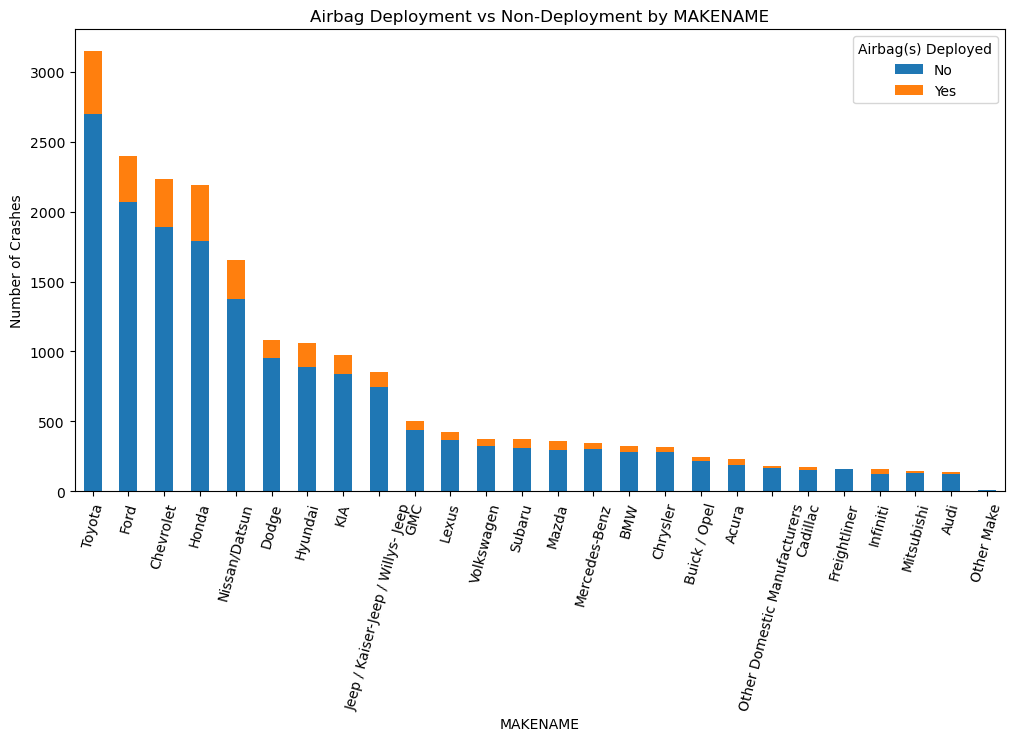

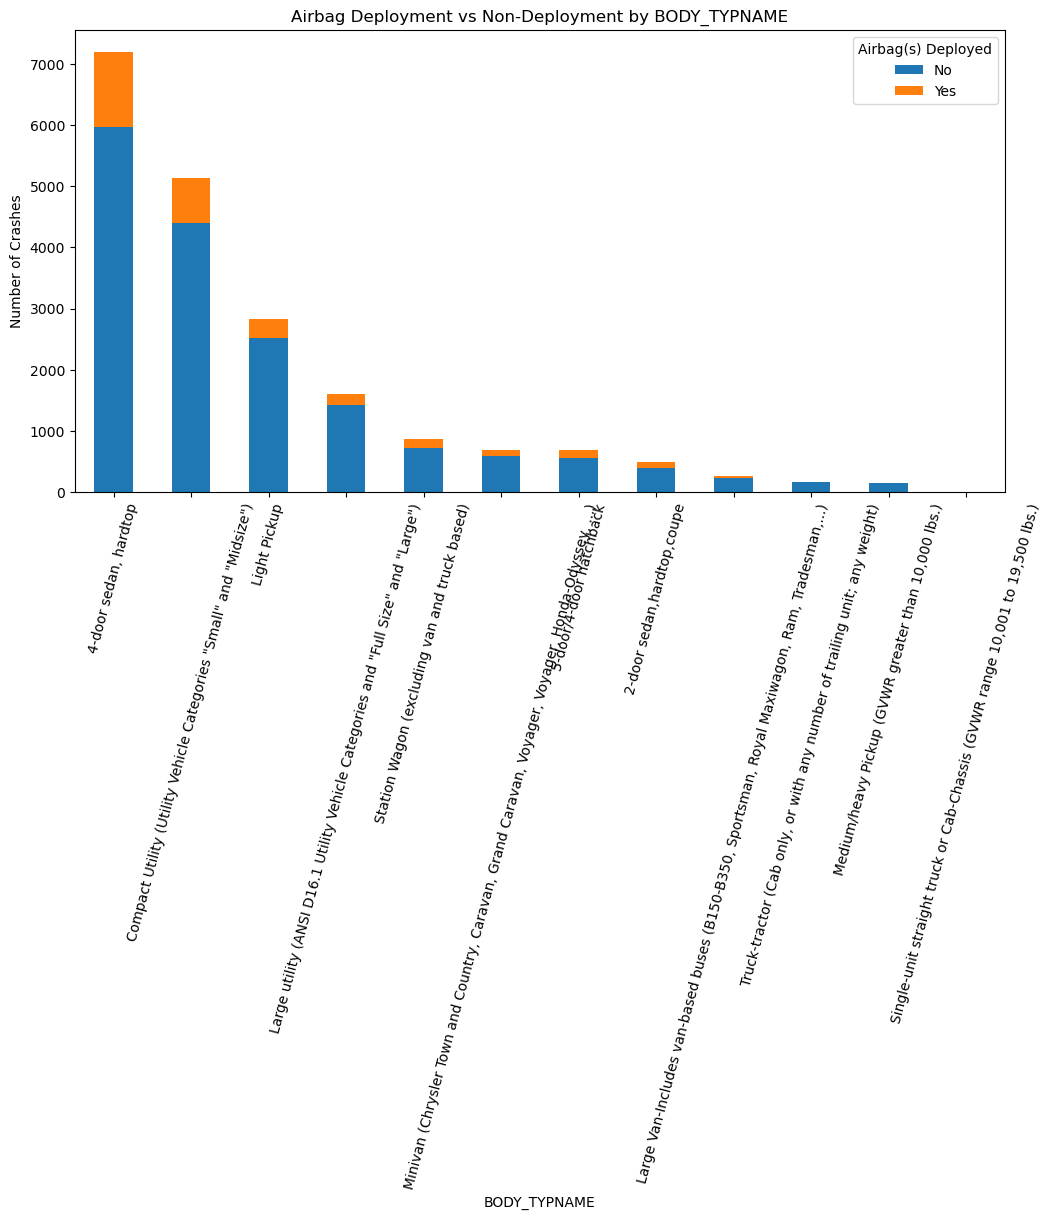

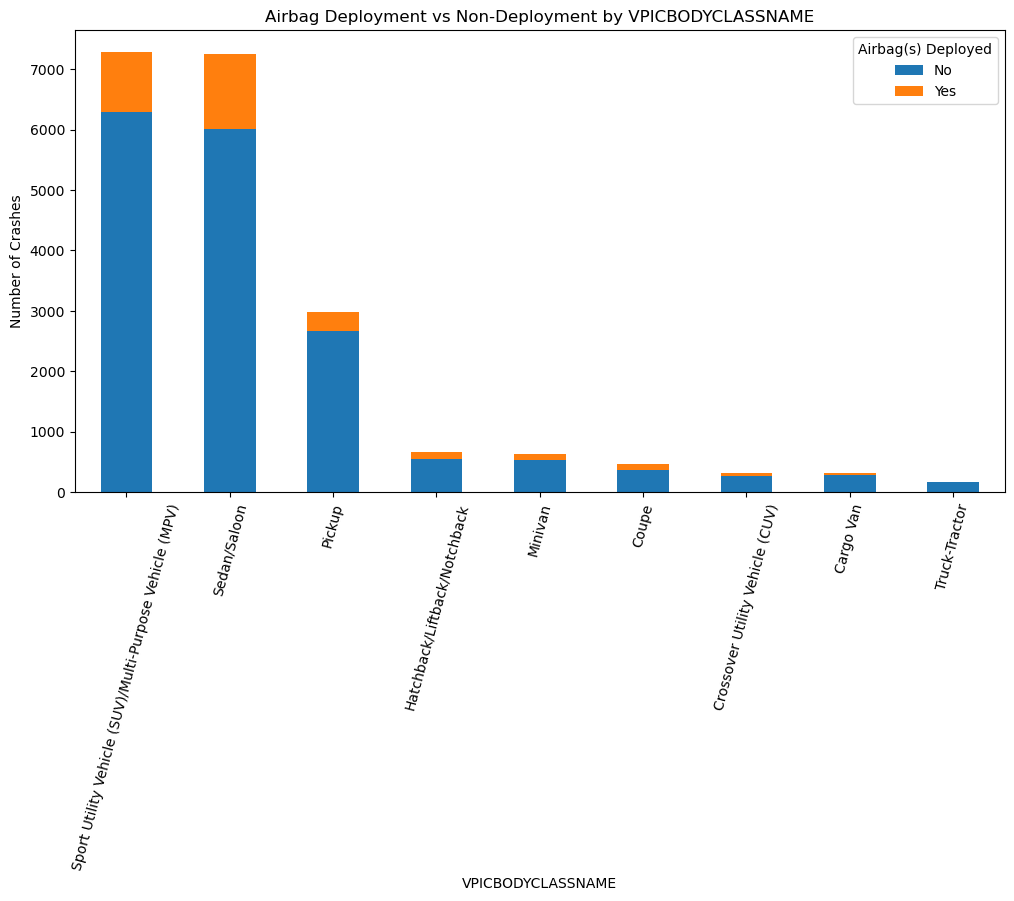

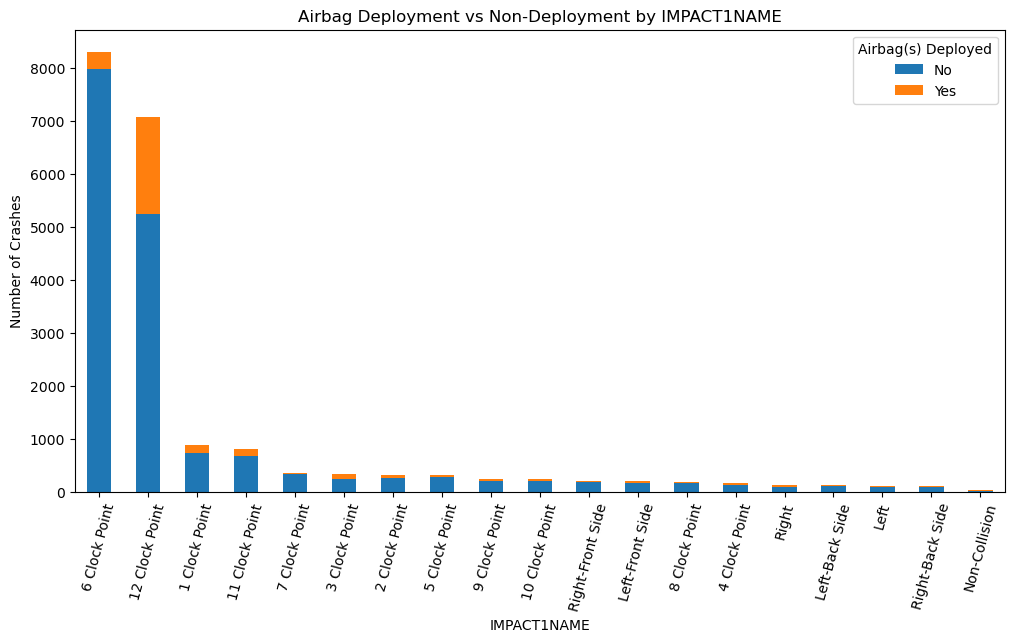

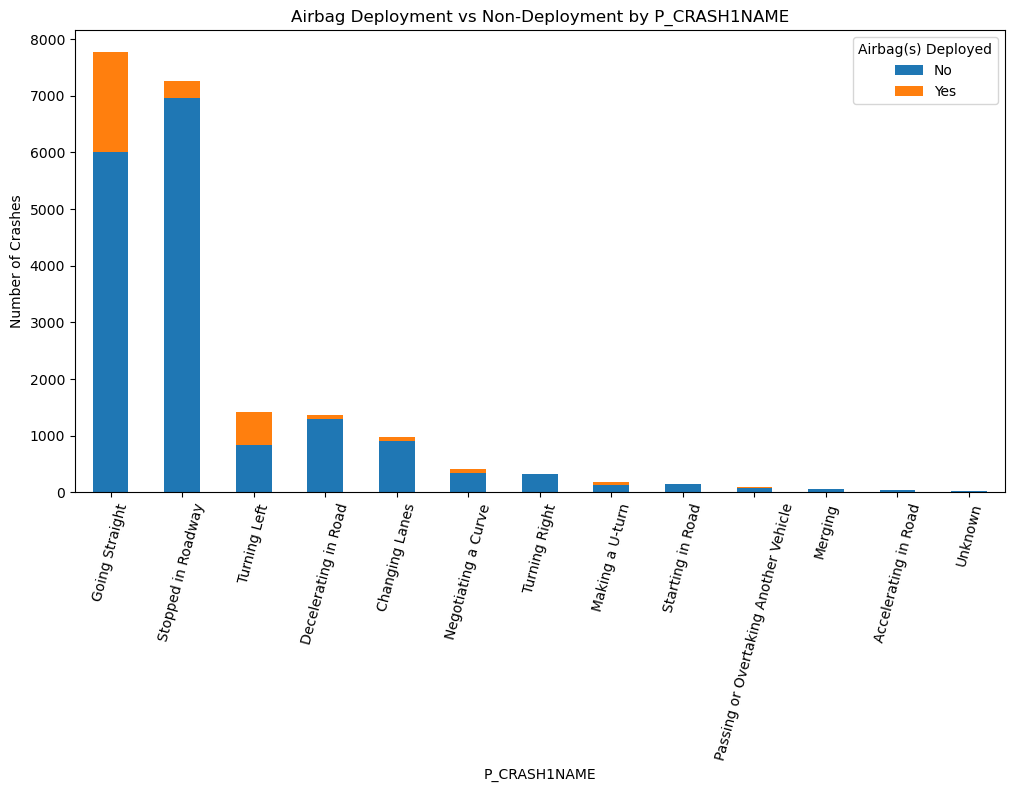

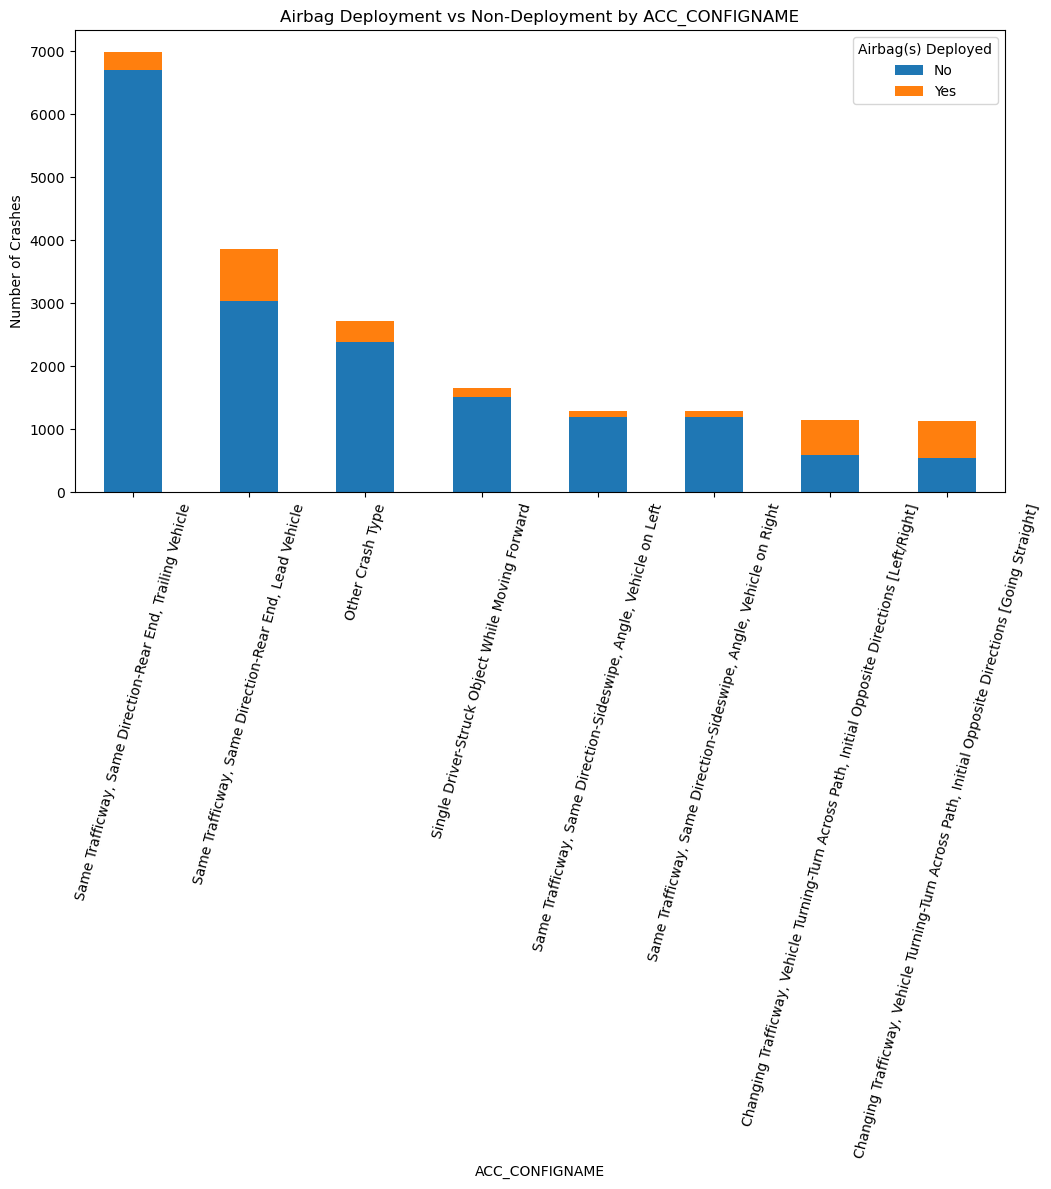

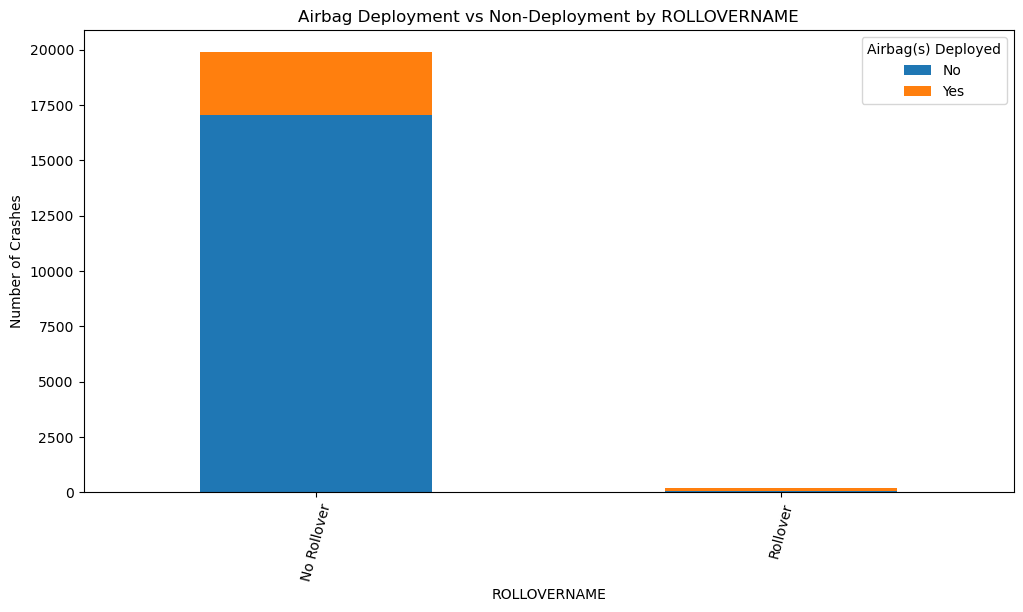

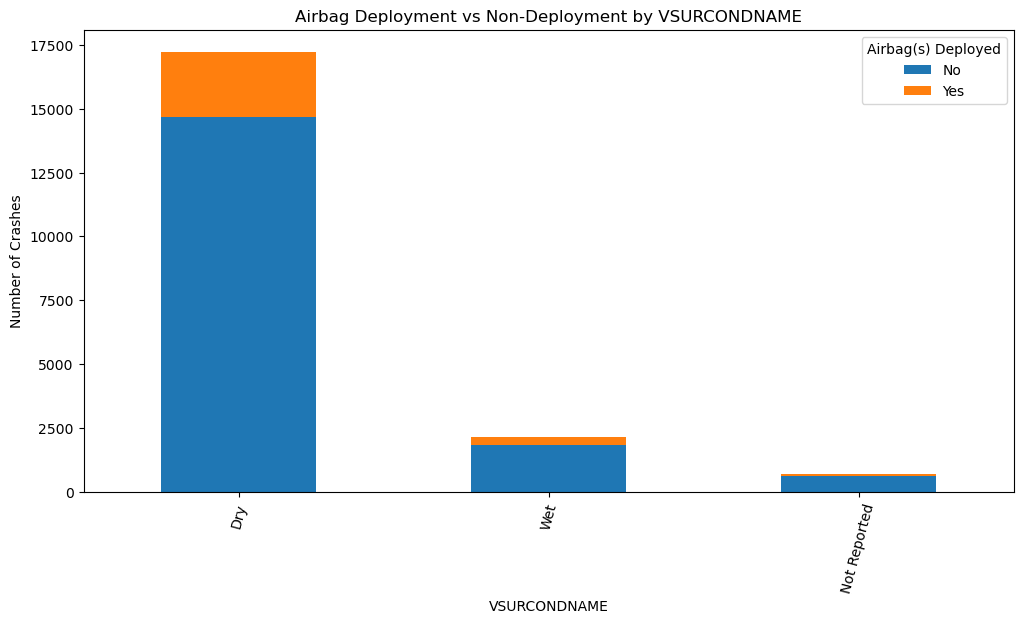

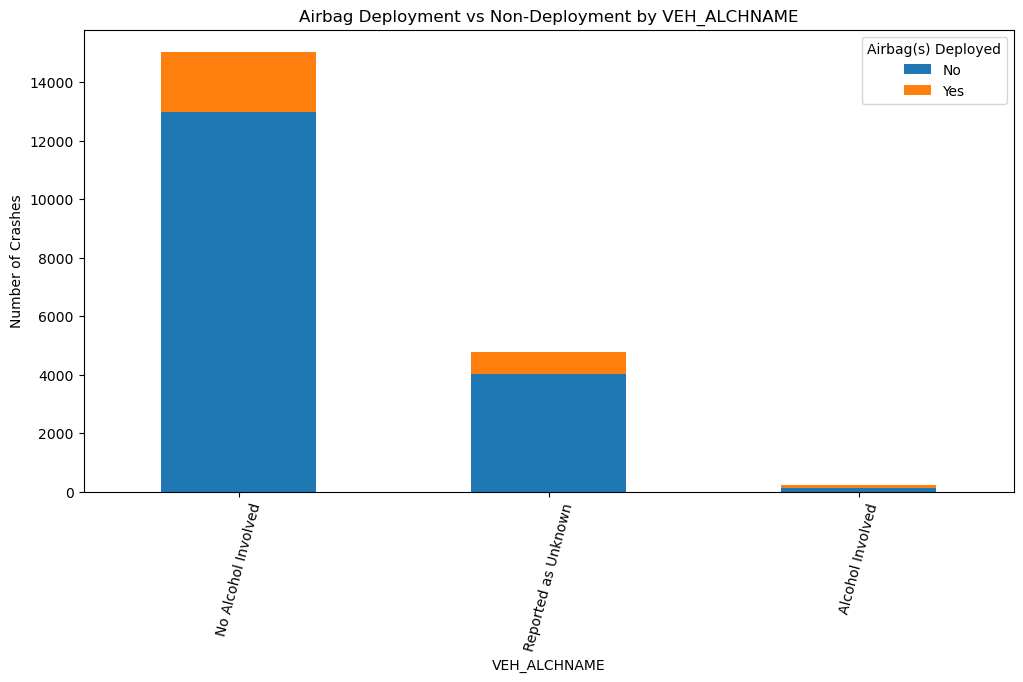

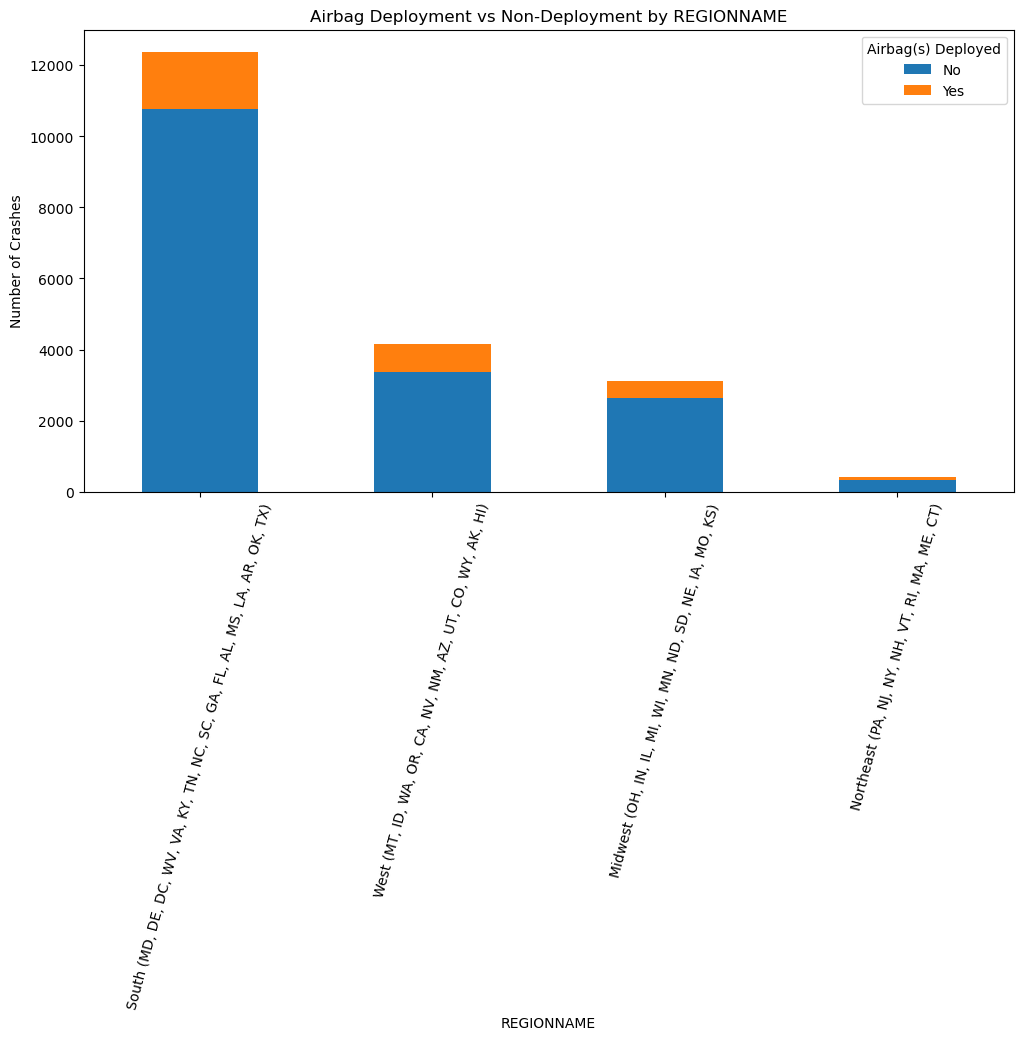

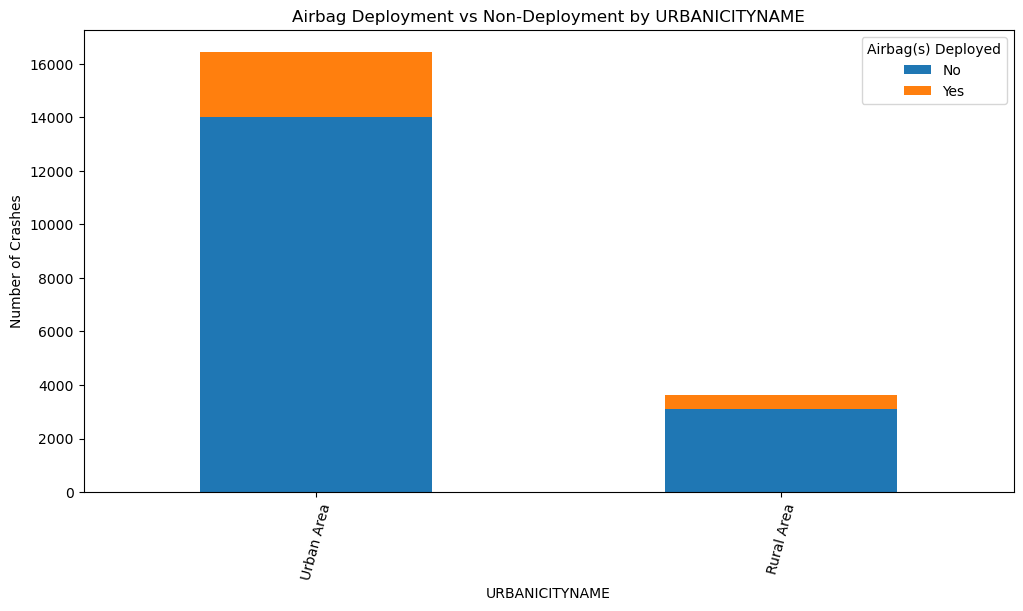

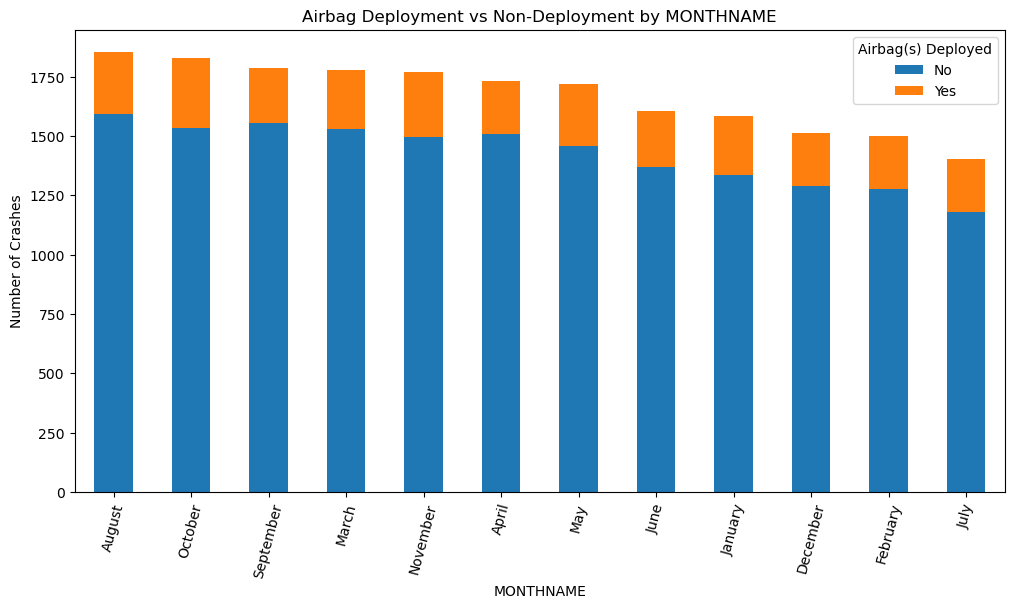

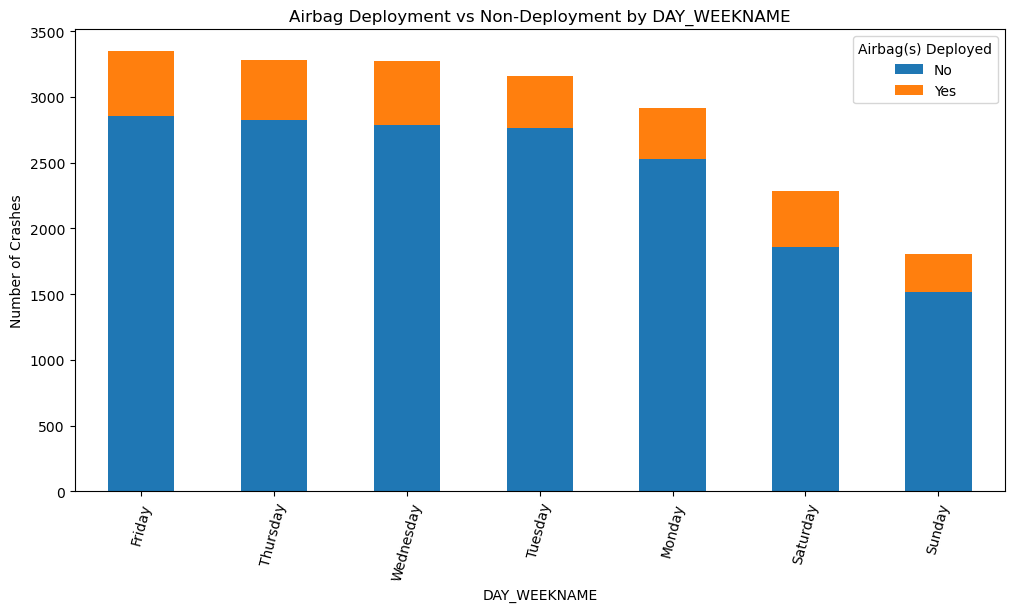

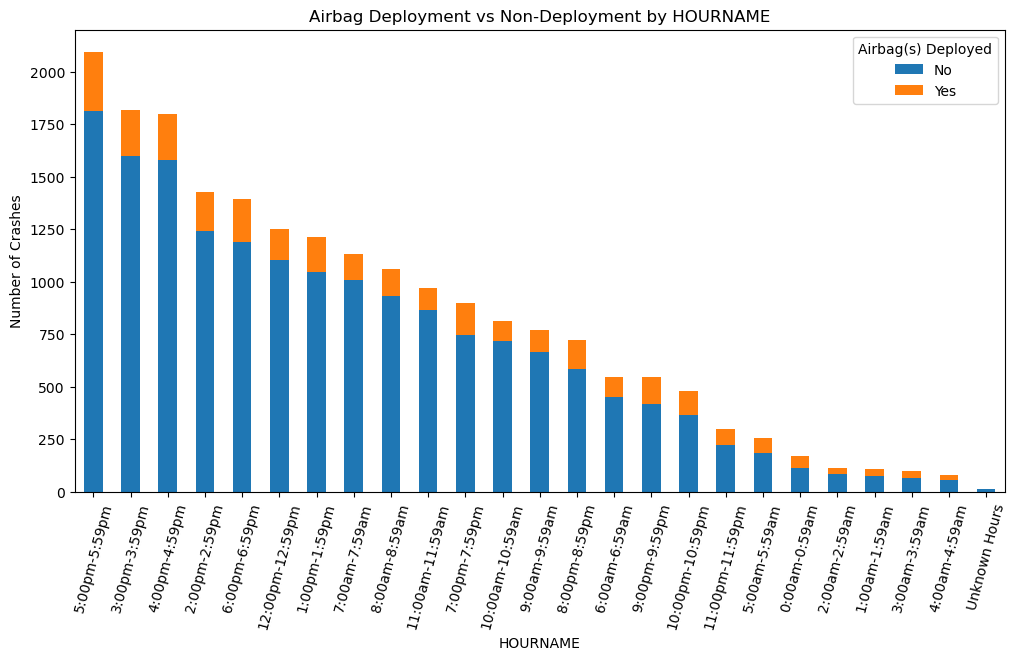

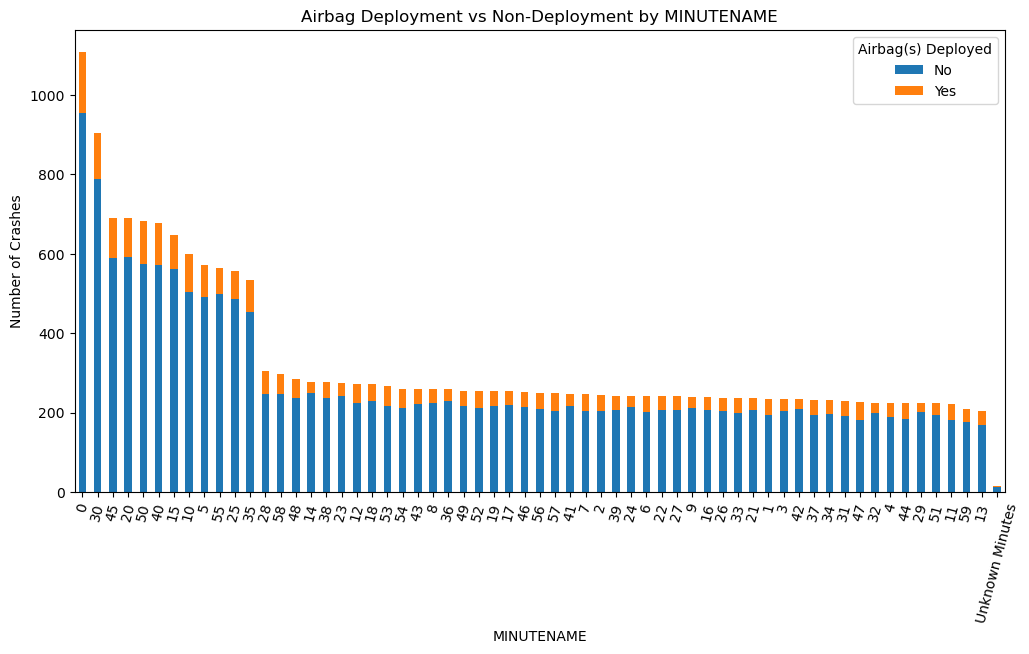

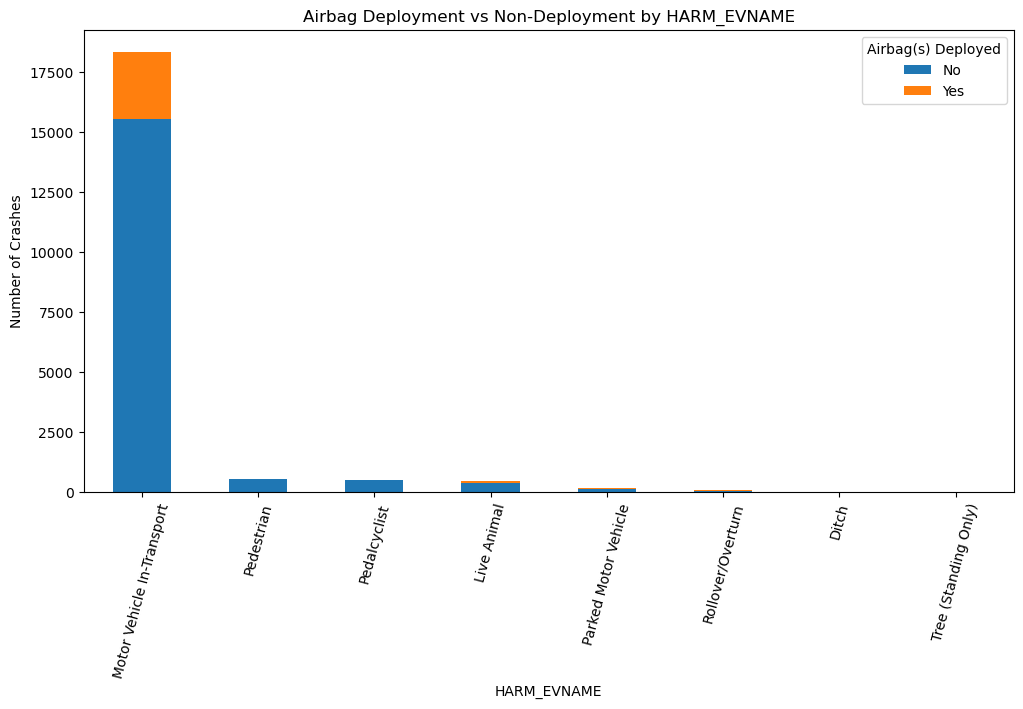

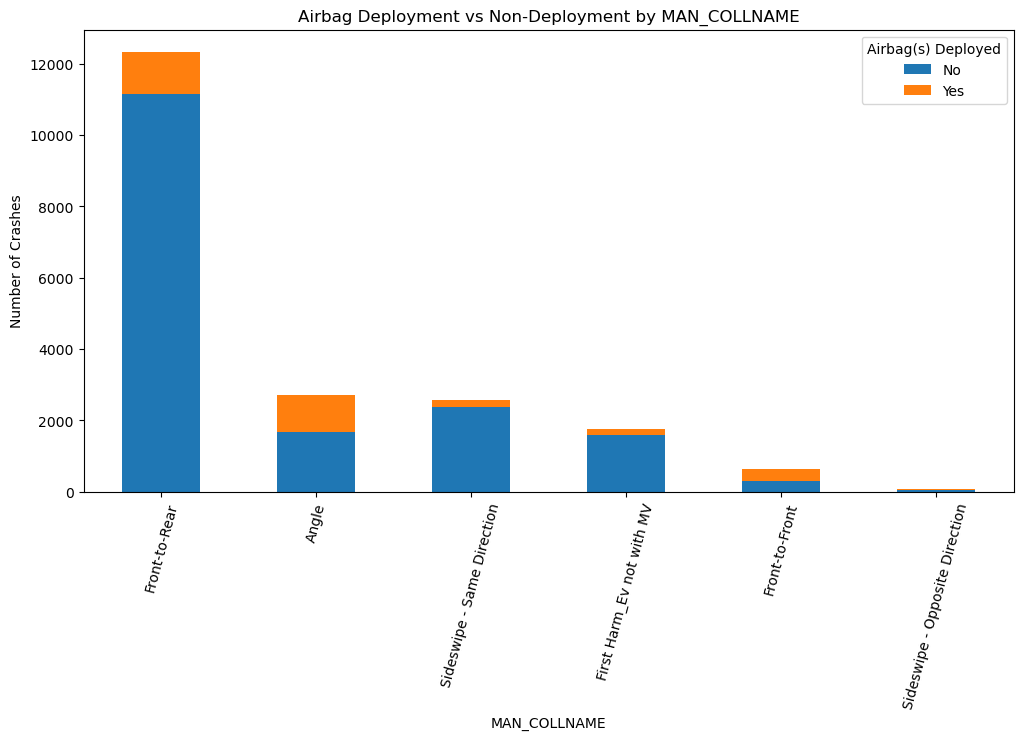

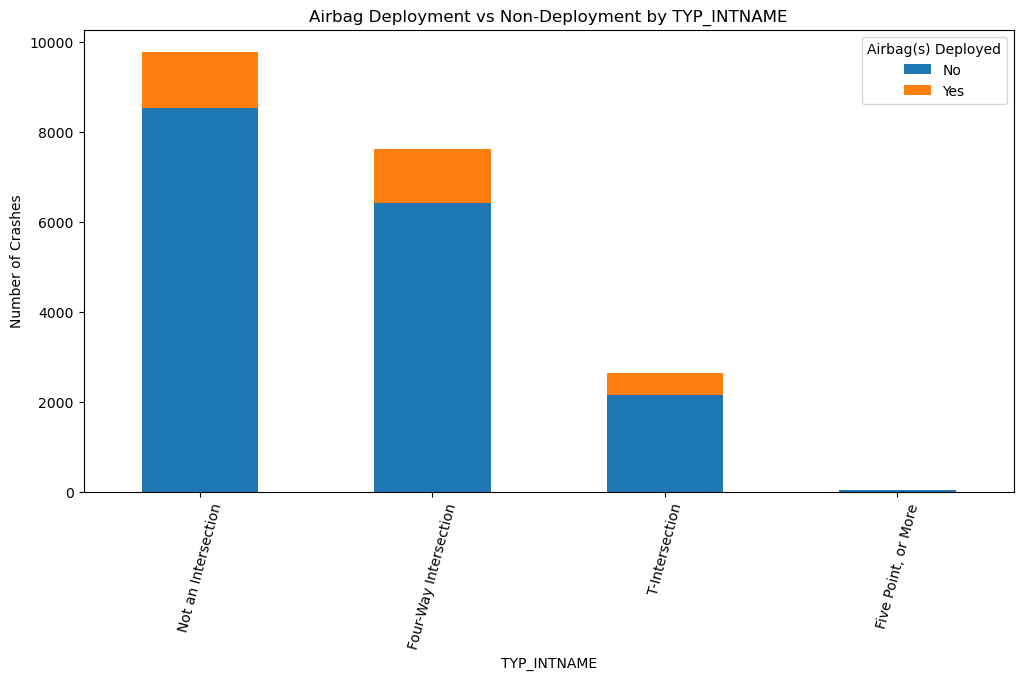

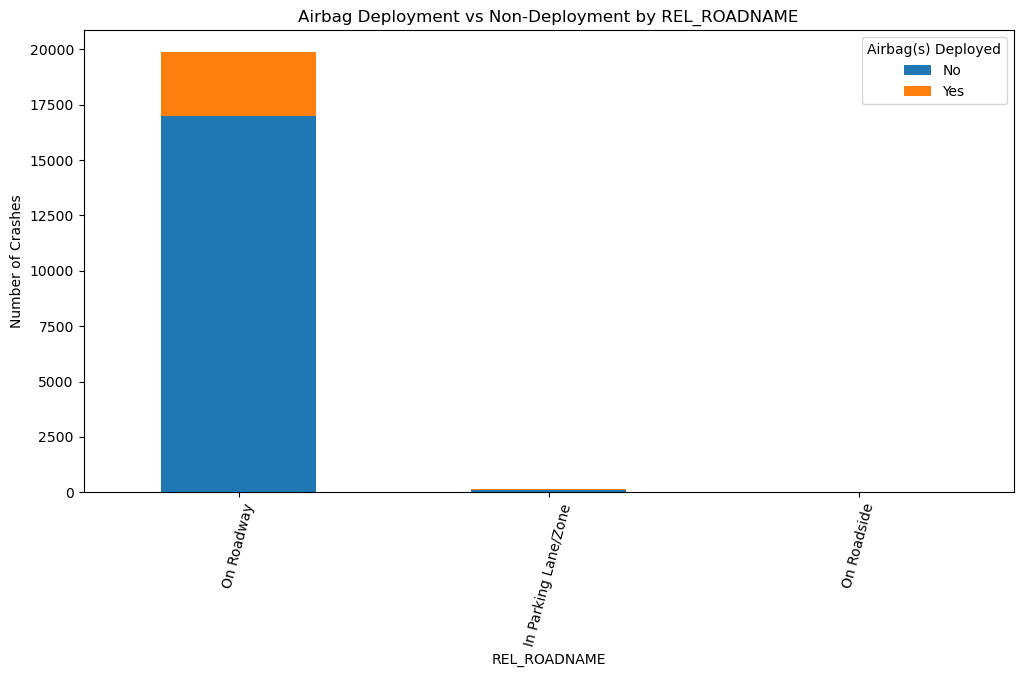

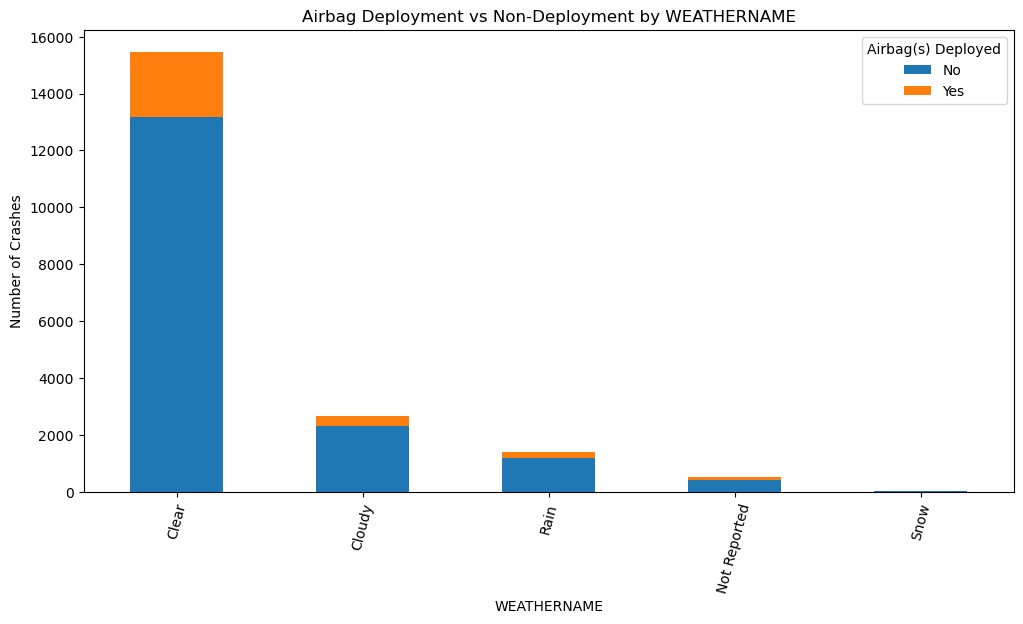

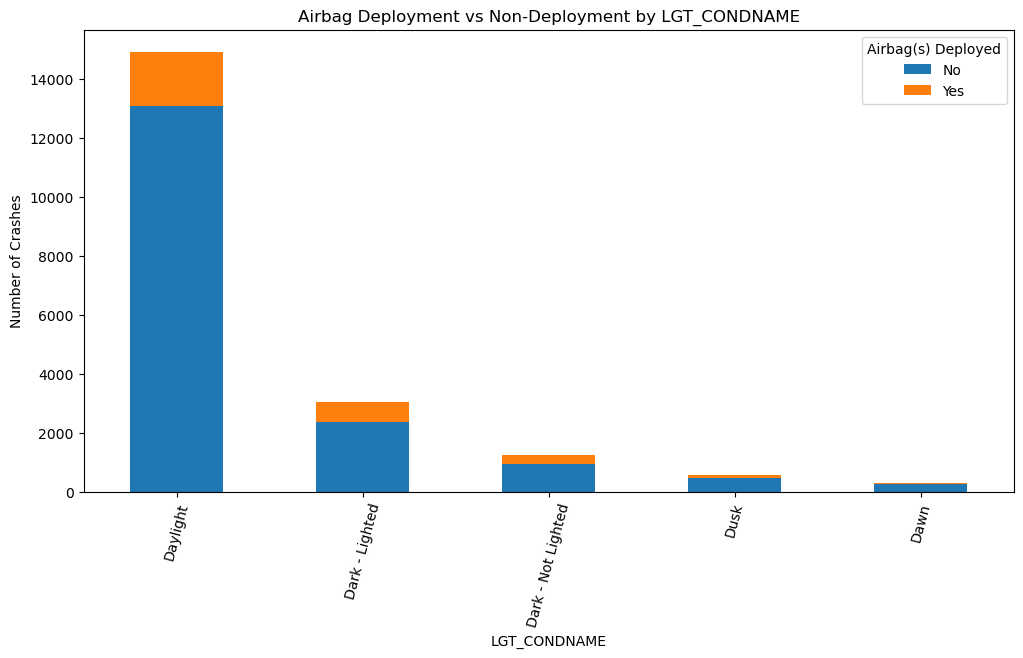

In [9]:
# function for bar plots
def plot_it(col, rot):
    summary = df.groupby([col, 'ALL_AIRBAGS_DEPLOYED']).size().reset_index(name='Count')
    summary_pivot = summary.pivot(index=col, columns='ALL_AIRBAGS_DEPLOYED', values='Count')

    summary_pivot = summary_pivot.loc[summary_pivot.sum(axis=1).sort_values(ascending=False).index]

    summary_pivot.plot(kind='bar', stacked=True, figsize=(12,6))
    plt.title(f'Airbag Deployment vs Non-Deployment by {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Crashes')
    plt.legend(labels=['No', 'Yes'], title='Airbag(s) Deployed')
    plt.xticks(rotation=rot)
    plt.show()

# bar plots to see distribution between airbag deployment 
for col in cat_cols:
    plot_it(col,75)


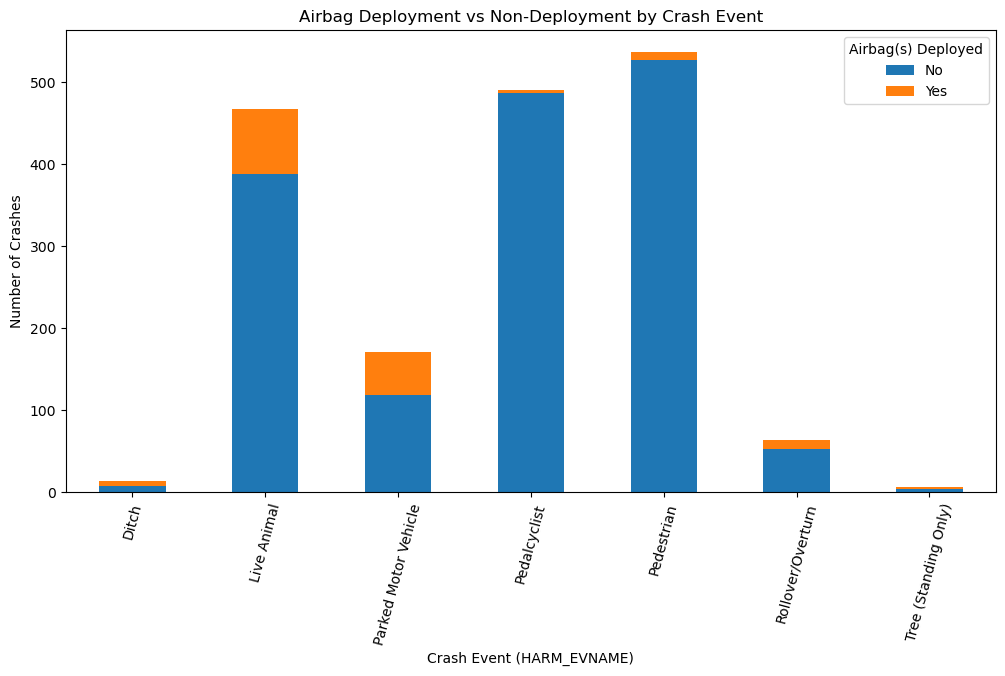

In [11]:
# see harm_ev relationship to air bag deployment 
# remove to see general data
df_ = df[df['HARM_EVNAME'] != 'Motor Vehicle In-Transport']


summary = df_.groupby(['HARM_EVNAME', 'ALL_AIRBAGS_DEPLOYED']).size().reset_index(name='Count')
summary_pivot = summary.pivot(index='HARM_EVNAME', columns='ALL_AIRBAGS_DEPLOYED', values='Count')
summary_pivot.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Airbag Deployment vs Non-Deployment by Crash Event')
plt.xlabel('Crash Event (HARM_EVNAME)')
plt.ylabel('Number of Crashes')
plt.legend(labels=['No', 'Yes'], title='Airbag(s) Deployed')
plt.xticks(rotation=75)
plt.show()

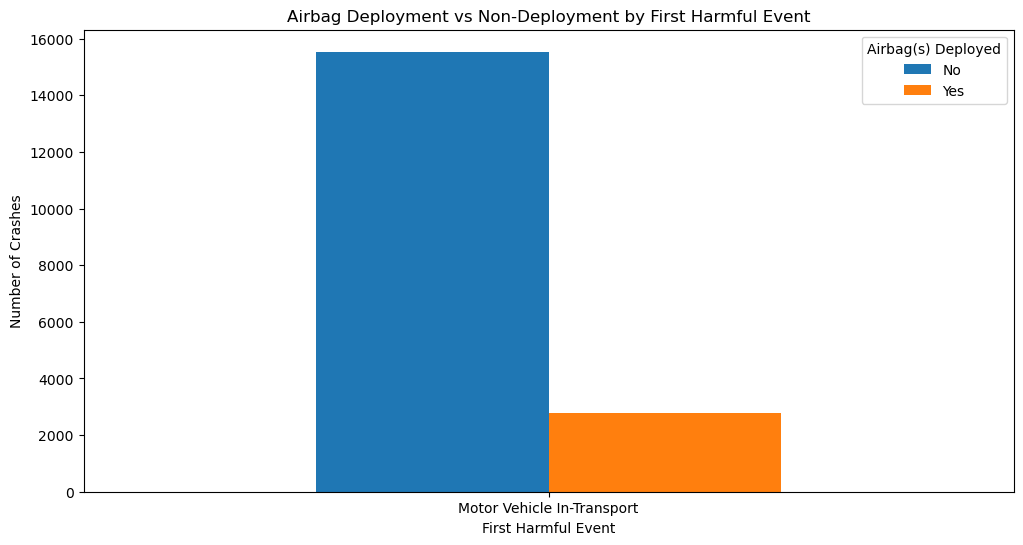

In [20]:
# remove to see general data
df_ = df[df['HARM_EVNAME'] == 'Motor Vehicle In-Transport']


summary = df_.groupby(['HARM_EVNAME', 'ALL_AIRBAGS_DEPLOYED']).size().reset_index(name='Count')
summary['HARM_EVNAME'] = summary['HARM_EVNAME'].replace({"Tree (Standing Only)": "Tree"})
summary_pivot = summary.pivot(index='HARM_EVNAME', columns='ALL_AIRBAGS_DEPLOYED', values='Count')
summary_pivot.plot(kind='bar', stacked=False, figsize=(12,6))
plt.title('Airbag Deployment vs Non-Deployment by First Harmful Event')
plt.xlabel('First Harmful Event')
plt.ylabel('Number of Crashes')
plt.legend(labels=['No', 'Yes'], title='Airbag(s) Deployed')
plt.xticks(rotation=0)
plt.show()


In [21]:
ct_ps = pd.crosstab(df['ALL_AIRBAGS_DEPLOYED'], df['HARM_EVNAME'])
ct_ps

HARM_EVNAME,Ditch,Live Animal,Motor Vehicle In-Transport,Parked Motor Vehicle,Pedalcyclist,Pedestrian,Rollover/Overturn,Tree (Standing Only)
ALL_AIRBAGS_DEPLOYED,,,,,,,,
0,8,388,15542,118,487,528,53,4
1,6,80,2777,53,4,9,11,2


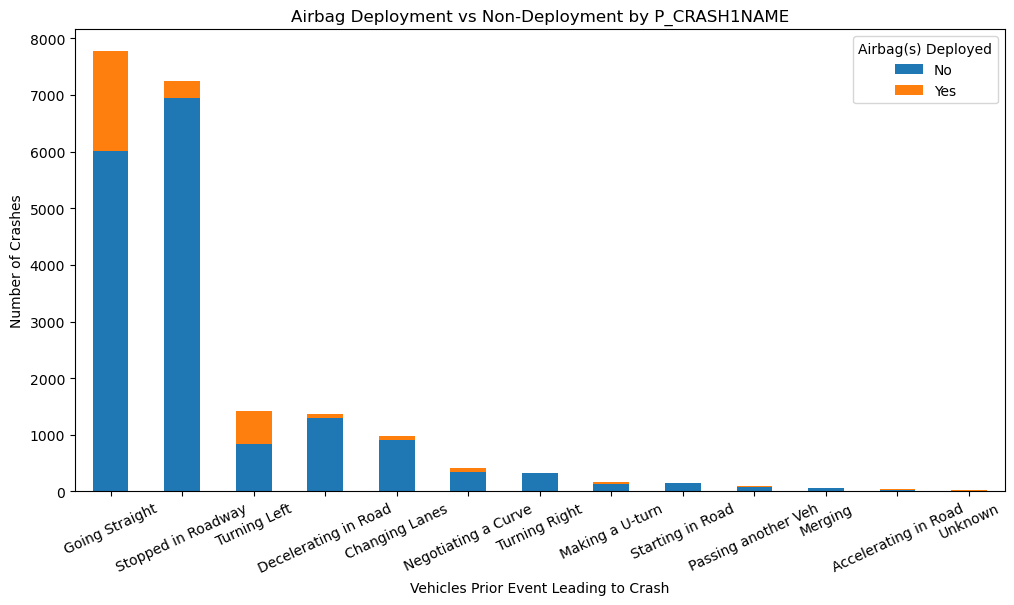

In [25]:
col = 'P_CRASH1NAME'
summary = df.groupby([col, 'ALL_AIRBAGS_DEPLOYED']).size().reset_index(name='Count')
summary[col] = summary[col].replace({"Passing or Overtaking Another Vehicle": "Passing another Veh"})

summary_pivot = summary.pivot(index=col, columns='ALL_AIRBAGS_DEPLOYED', values='Count')

summary_pivot = summary_pivot.loc[summary_pivot.sum(axis=1).sort_values(ascending=False).index]

summary_pivot.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title(f'Airbag Deployment vs Non-Deployment by {col}')
plt.xlabel('Vehicles Prior Event Leading to Crash')
plt.ylabel('Number of Crashes')
plt.legend(labels=['No', 'Yes'], title='Airbag(s) Deployed')
plt.xticks(rotation=25)
plt.show()


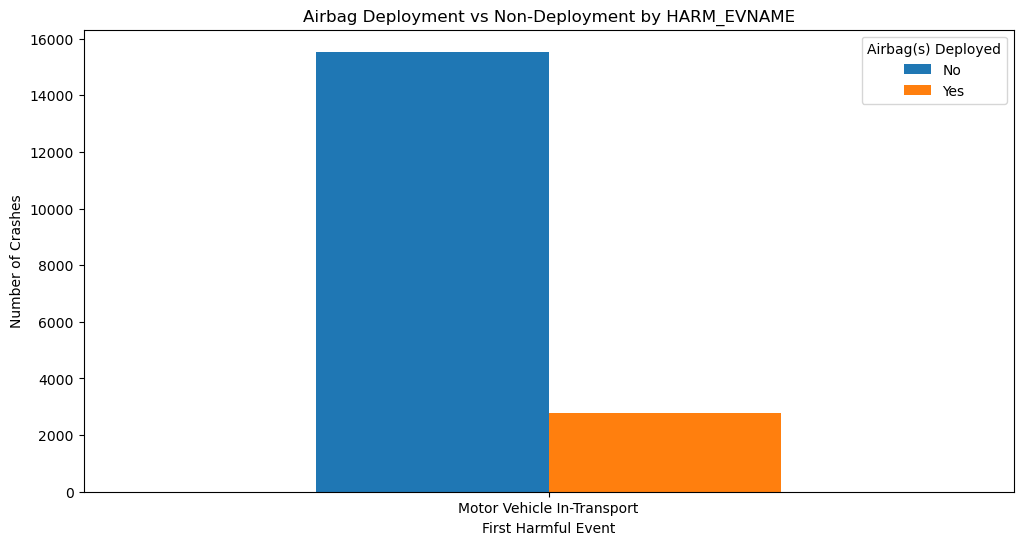

In [26]:
col = 'HARM_EVNAME'
summary = df.groupby([col, 'ALL_AIRBAGS_DEPLOYED']).size().reset_index(name='Count')
summary= summary[summary['HARM_EVNAME'] == "Motor Vehicle In-Transport"]
summary_pivot = summary.pivot(index=col, columns='ALL_AIRBAGS_DEPLOYED', values='Count')

summary_pivot = summary_pivot.loc[summary_pivot.sum(axis=1).sort_values(ascending=False).index]

summary_pivot.plot(kind='bar', stacked=False, figsize=(12,6))
plt.title(f'Airbag Deployment vs Non-Deployment by {col}')
plt.xlabel('First Harmful Event')
plt.ylabel('Number of Crashes')
plt.legend(labels=['No', 'Yes'], title='Airbag(s) Deployed')
plt.xticks(rotation=0)
plt.show()

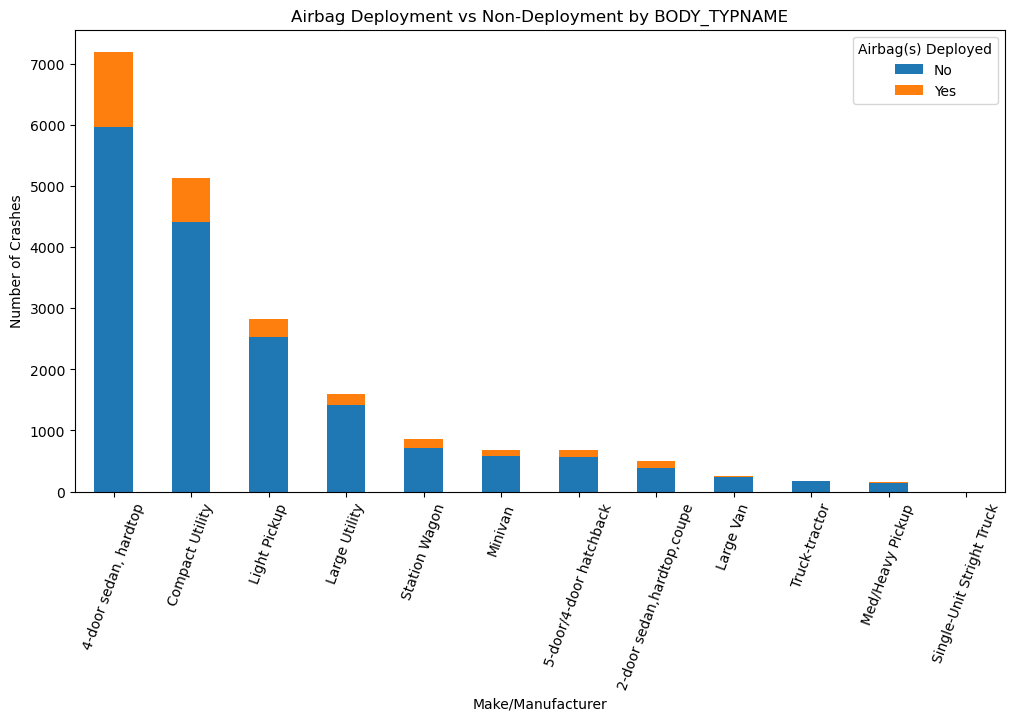

In [27]:
col = 'BODY_TYPNAME'
df[col] = df[col].replace({'Compact Utility (Utility Vehicle Categories "Small" and "Midsize")': "Compact Utility"})
df[col] = df[col].replace({'Large utility (ANSI D16.1 Utility Vehicle Categories and "Full Size" and "Large")': "Large Utility"})
df[col] = df[col].replace({"Station Wagon (excluding van and truck based)": "Station Wagon"})
df[col] = df[col].replace({"Minivan (Chrysler Town and Country, Caravan, Grand Caravan, Voyager, Voyager, Honda-Odyssey, ...)": "Minivan"})
df[col] = df[col].replace({"Truck-tractor (Cab only, or with any number of trailing unit; any weight)": "Truck-tractor"})
df[col] = df[col].replace({"Large Van-Includes van-based buses (B150-B350, Sportsman, Royal Maxiwagon, Ram, Tradesman,...)": "Large Van"})
df[col] = df[col].replace({"Single-unit straight truck or Cab-Chassis (GVWR range 10,001 to 19,500 lbs.)": "Single-Unit Stright Truck"})
df[col] = df[col].replace({"Medium/heavy Pickup (GVWR greater than 10,000 lbs.)": "Med/Heavy Pickup"})


summary = df.groupby([col, 'ALL_AIRBAGS_DEPLOYED']).size().reset_index(name='Count')





summary_pivot = summary.pivot(index=col, columns='ALL_AIRBAGS_DEPLOYED', values='Count')

summary_pivot = summary_pivot.loc[summary_pivot.sum(axis=1).sort_values(ascending=False).index]

summary_pivot.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title(f'Airbag Deployment vs Non-Deployment by {col}')
plt.xlabel('Make/Manufacturer')
plt.ylabel('Number of Crashes')
plt.legend(labels=['No', 'Yes'], title='Airbag(s) Deployed')
plt.xticks(rotation=70)
plt.show()

In [28]:
num_cols = df.select_dtypes(include = 'int64').columns.tolist()
print(f'num of num vars: ', len(num_cols))
print(num_cols)

num of num vars:  42
['CASENUM', 'VEH_NO', 'MAKE', 'MOD_YEAR', 'MODEL', 'BODY_TYP', 'VPICBODYCLASS', 'IMPACT1', 'P_CRASH1', 'ACC_CONFIG', 'VSPD_LIM', 'TRAV_SP', 'ROLLOVER', 'NUMOCCS', 'VSURCOND', 'VEH_ALCH', 'AIRBAGS_DEPLOYED_COUNT', 'TOTAL_OCCUPANTS', 'PREDOMINANT_SEX', 'MAX_INJURY_SEV', 'ANY_DRINKING', 'ANY_ALCOHOL', 'FRONT_MOST_SEAT_POS', 'ANY_UNRESTRAINED', 'MAX_EJECTION', 'ALL_AIRBAGS_DEPLOYED', 'MONTH', 'DAY_WEEK', 'YEAR', 'HOUR', 'MINUTE', 'HARM_EV', 'MAN_COLL', 'TYP_INT', 'REL_ROAD', 'WEATHER', 'LGT_COND', 'NUM_INJ', 'VEHICLE_AGE', 'FRONTAL_IMPACT', 'HIGH_SPEED_CRASH', 'MIN_AIRBAG_SPEED']


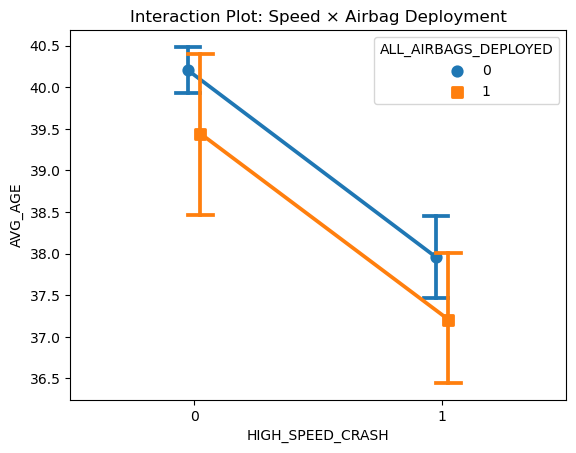

In [38]:

sns.pointplot(
    data=df,
    x="HIGH_SPEED_CRASH",
    y="AVG_AGE",
    hue="ALL_AIRBAGS_DEPLOYED",
    dodge=True,
    markers=['o', 's'],
    capsize=0.1
)
plt.title("Interaction Plot: Speed × Airbag Deployment")
plt.show()


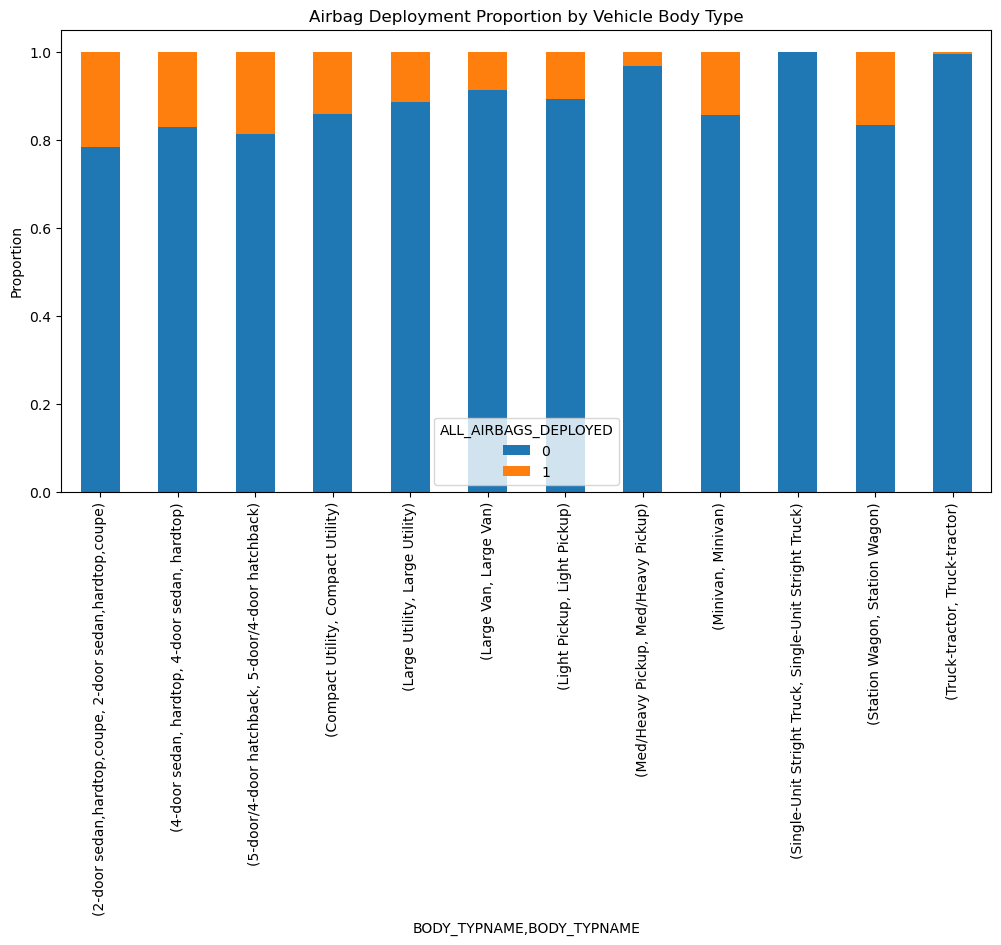

In [39]:
prop = df.groupby(['BODY_TYPNAME','ALL_AIRBAGS_DEPLOYED']).size()
prop = prop.groupby(level=0).apply(lambda x: x / x.sum()).unstack()

prop.plot(kind='bar', stacked=True, figsize=(12,6))
plt.ylabel("Proportion")
plt.title("Airbag Deployment Proportion by Vehicle Body Type")
plt.show()


In [40]:
# function for plotting interactions plots
def interaction_plot_cat(col,rot):
    rates = df.groupby(col)['ALL_AIRBAGS_DEPLOYED'].mean().reset_index()

    sns.pointplot(data=rates, x=col, y='ALL_AIRBAGS_DEPLOYED')
    plt.xticks(rotation=rot)
    plt.ylabel("Deployment Rate")
    plt.show()


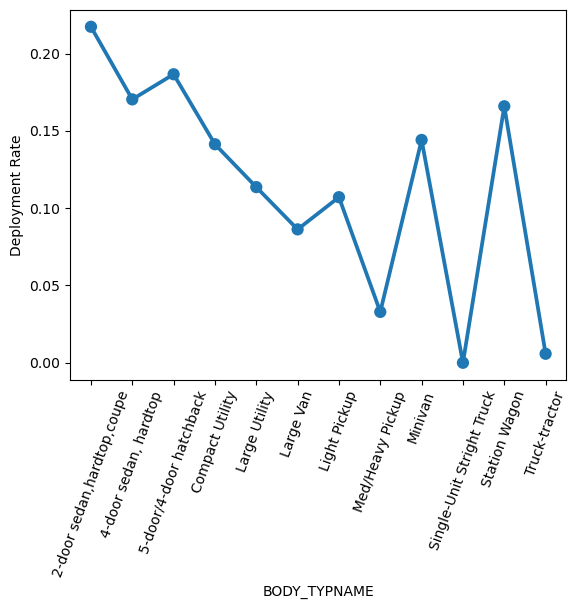

In [41]:
# test
interaction_plot_cat('BODY_TYPNAME', 70)

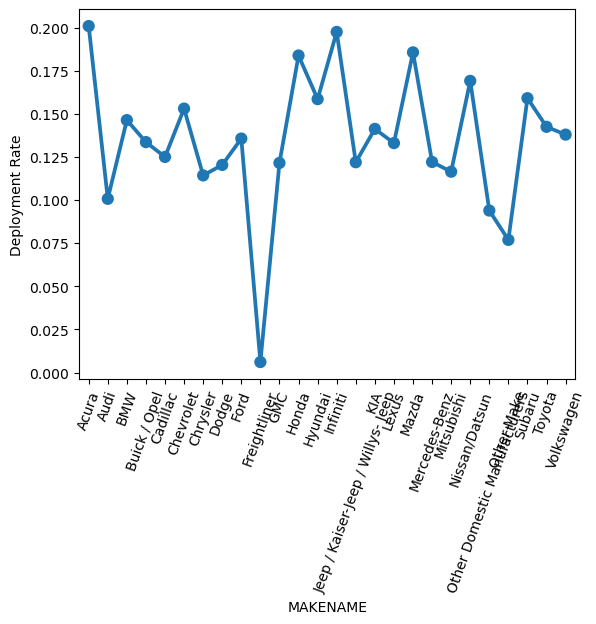

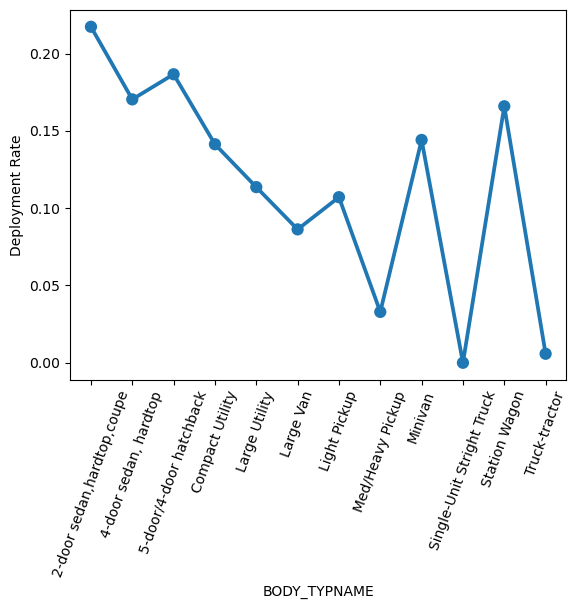

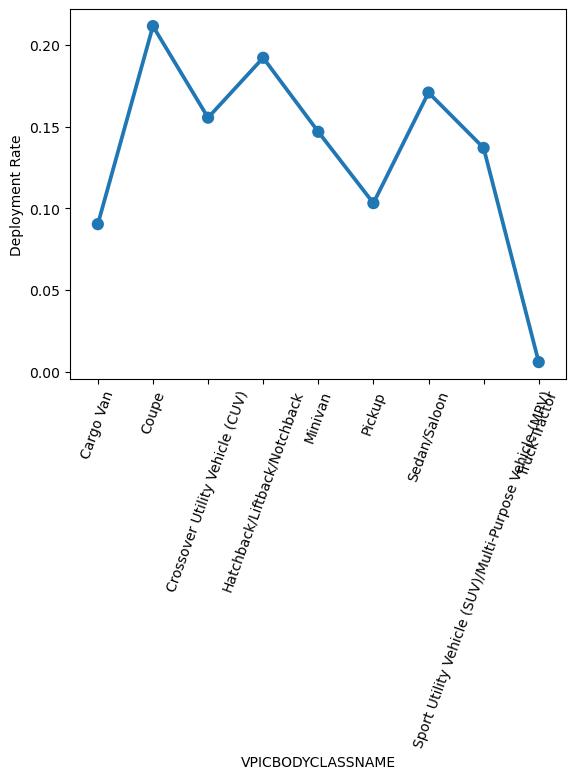

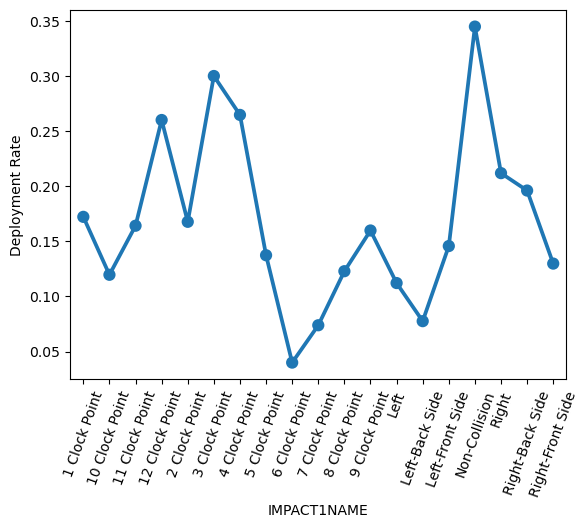

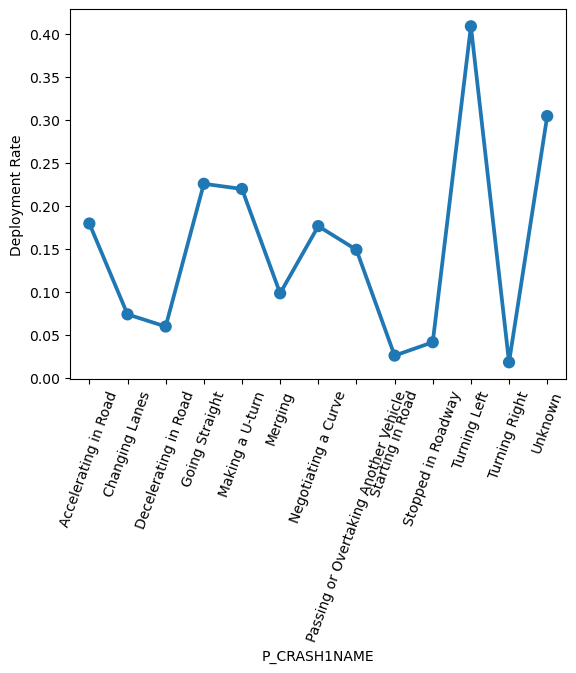

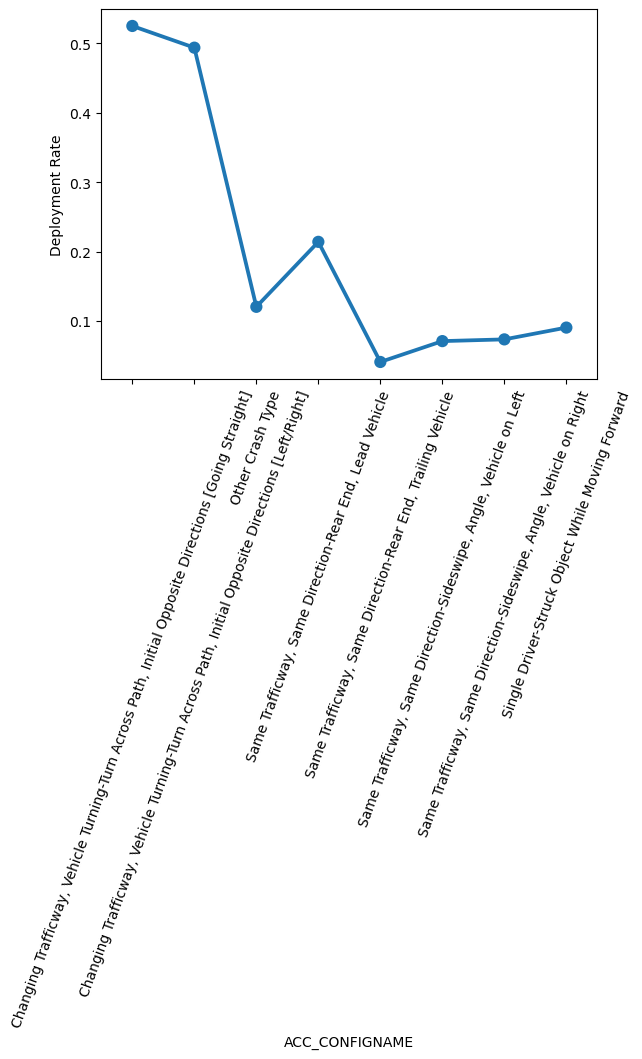

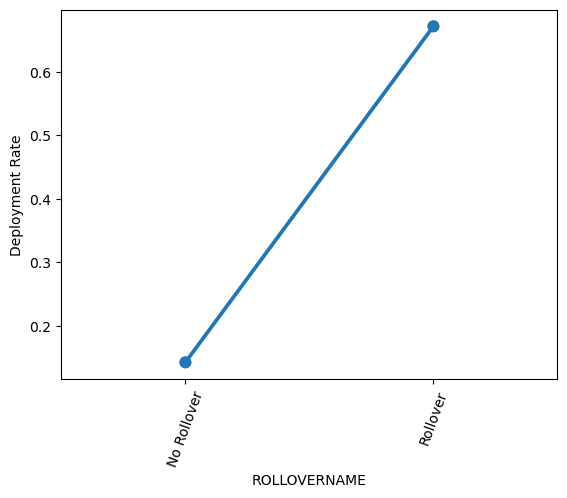

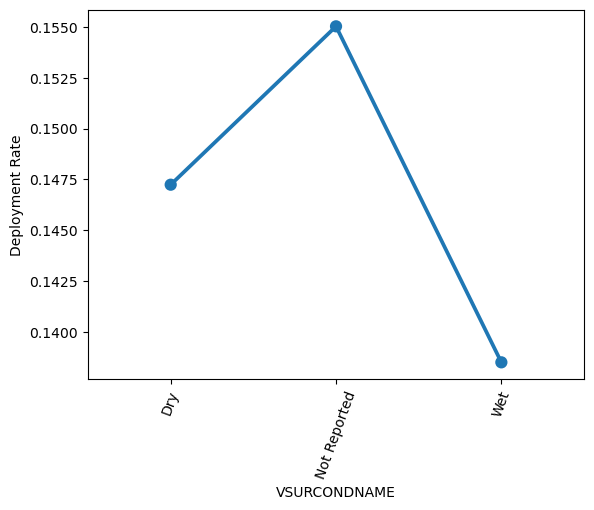

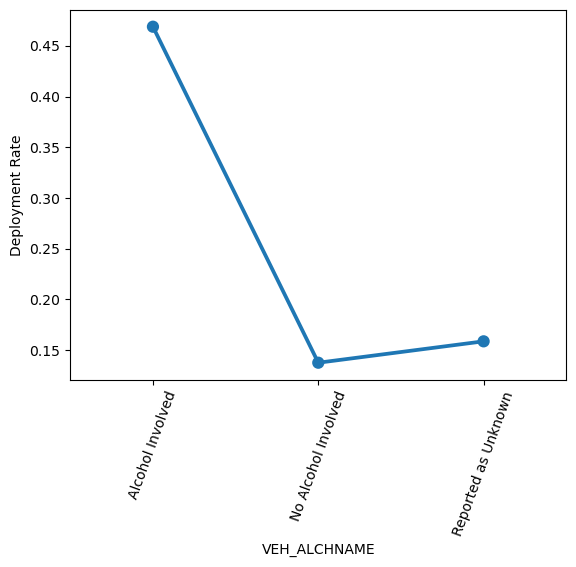

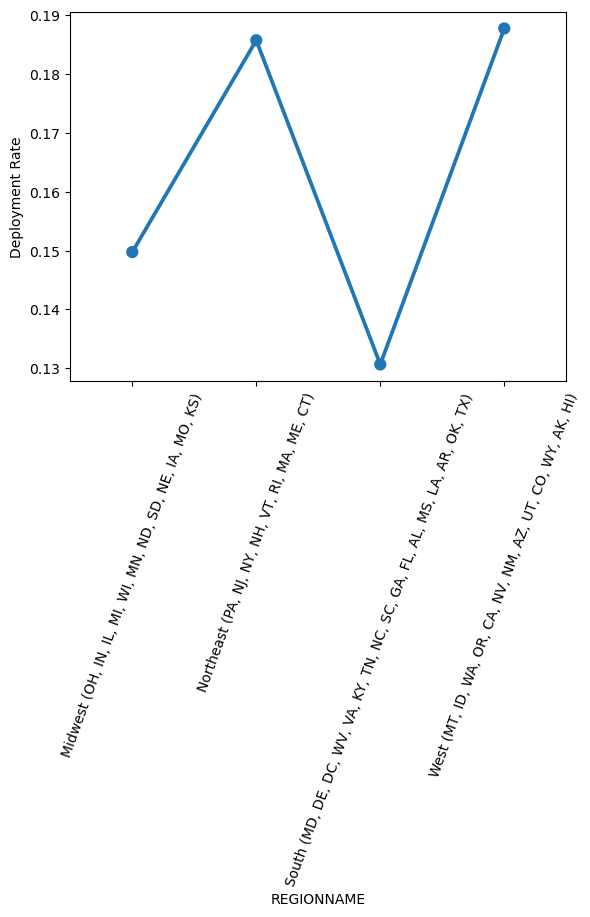

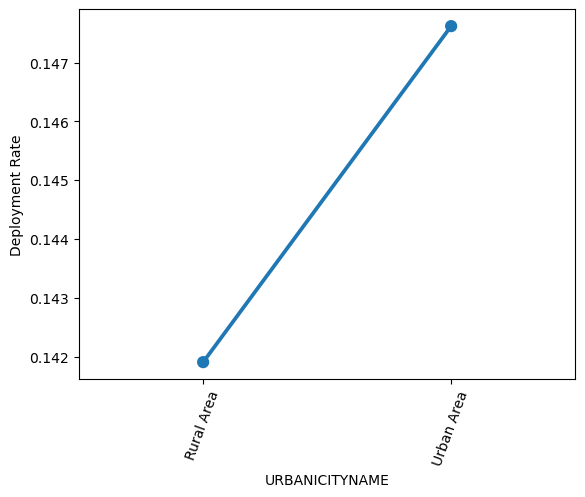

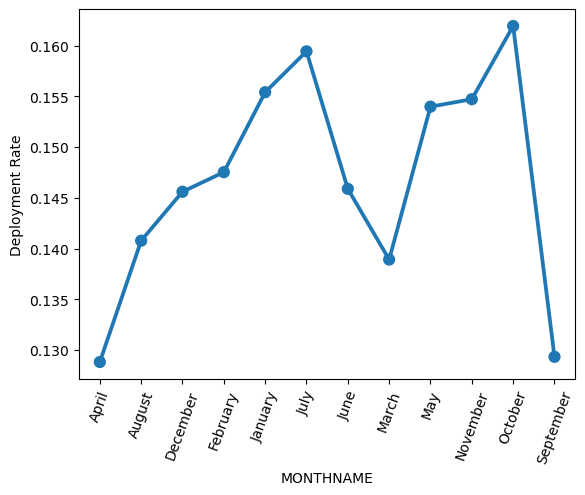

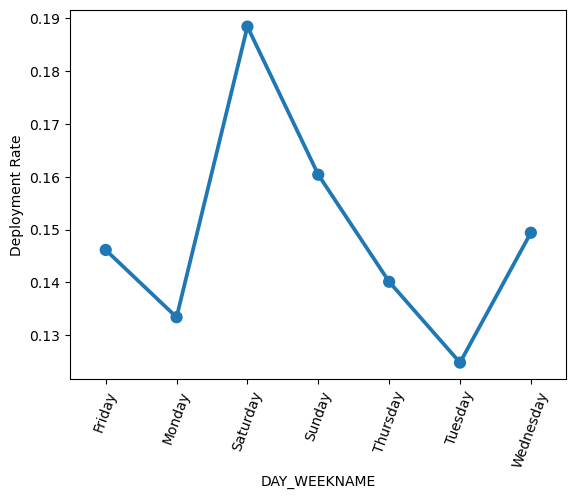

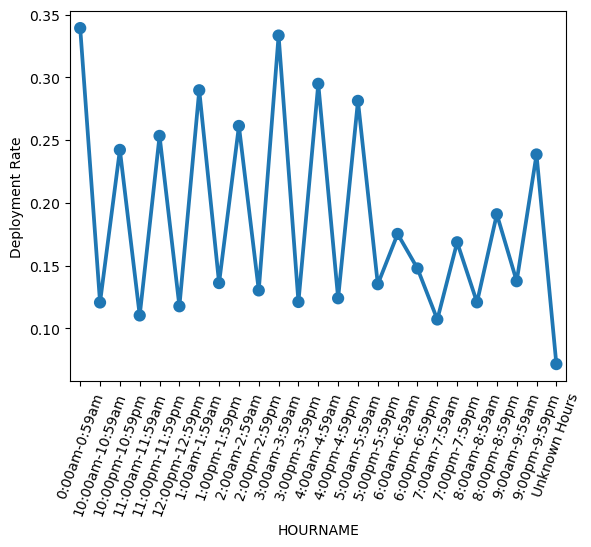

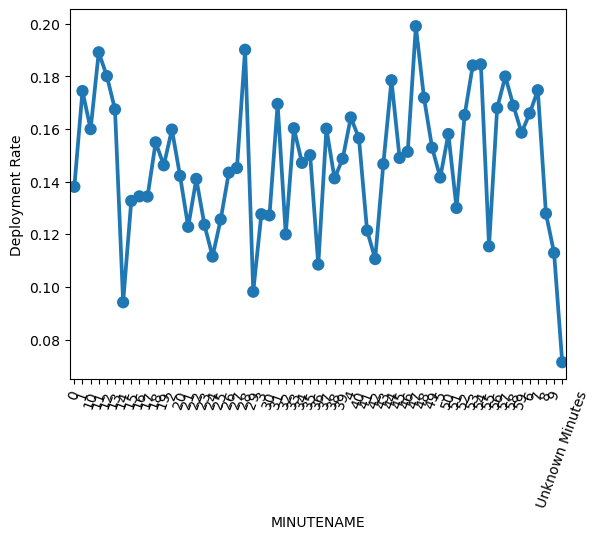

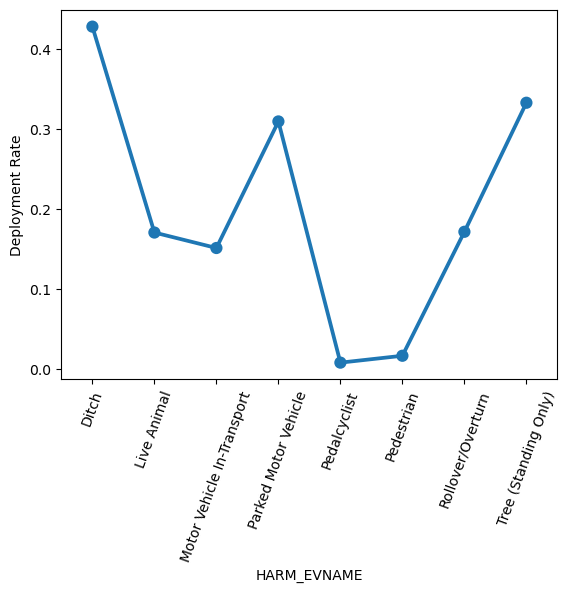

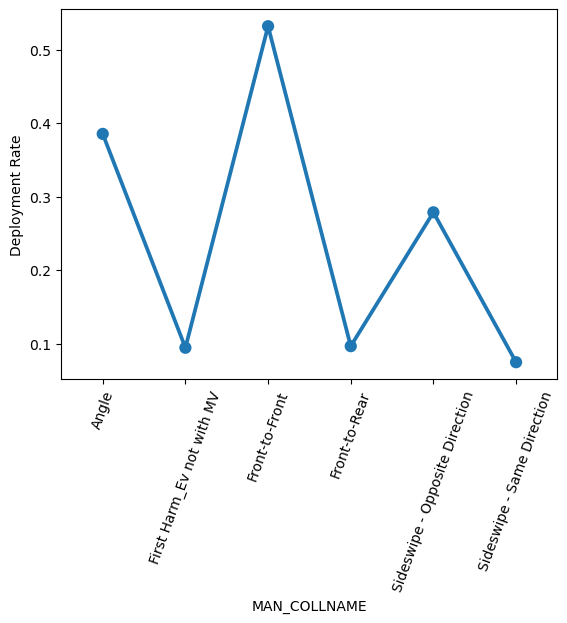

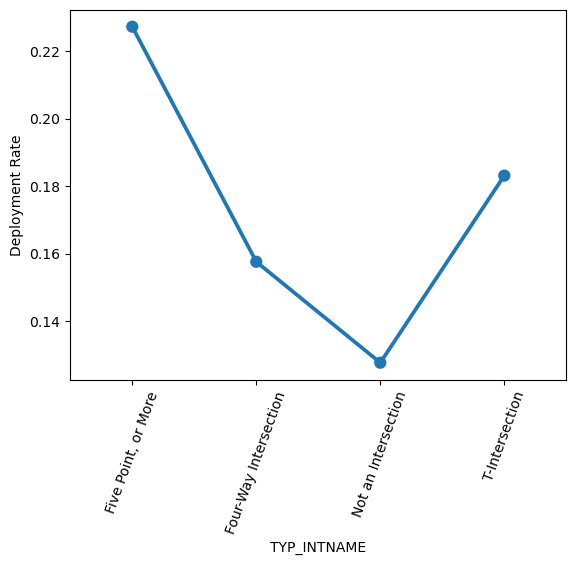

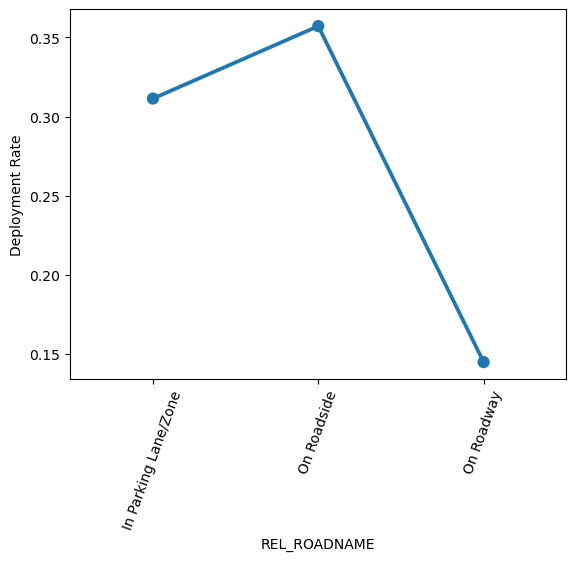

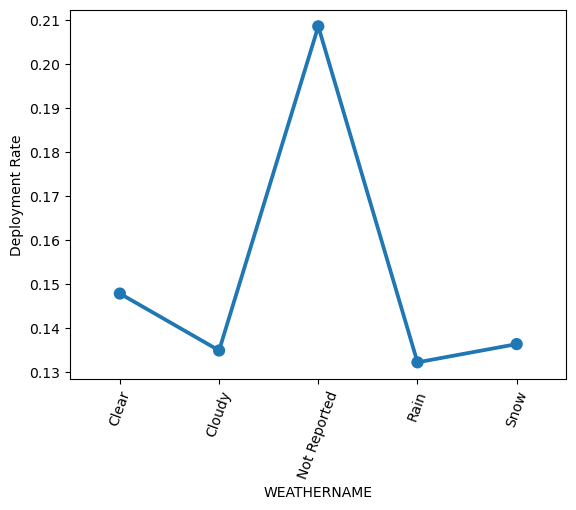

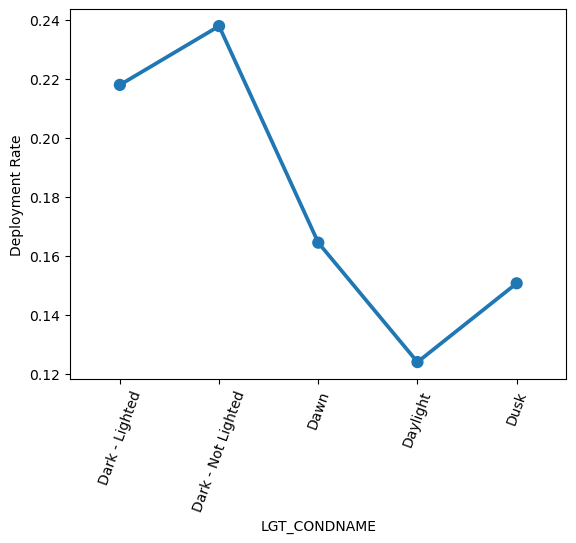

In [42]:
# interaction plots for car vars
for col in cat_cols:
    interaction_plot_cat(col,70)

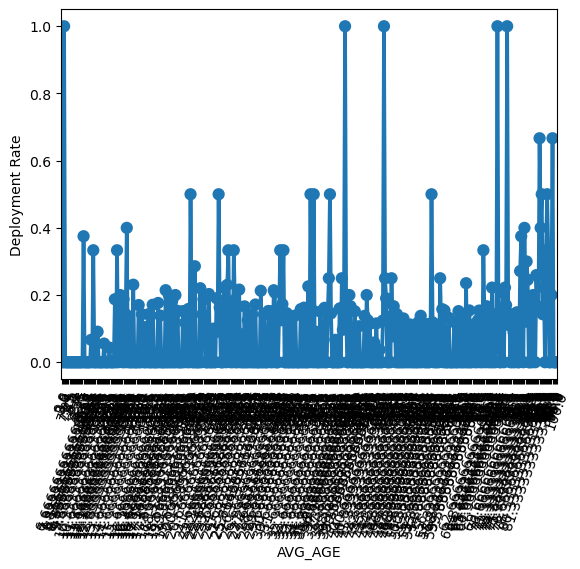

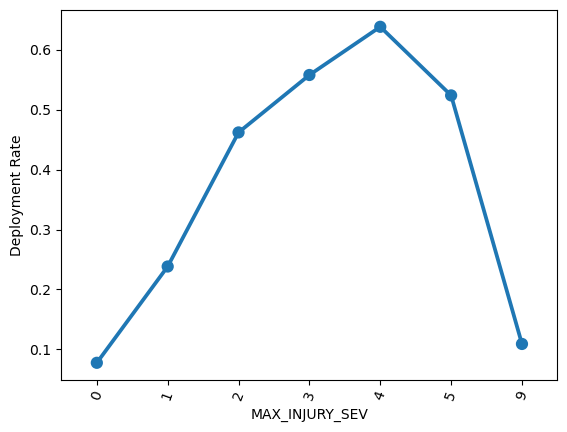

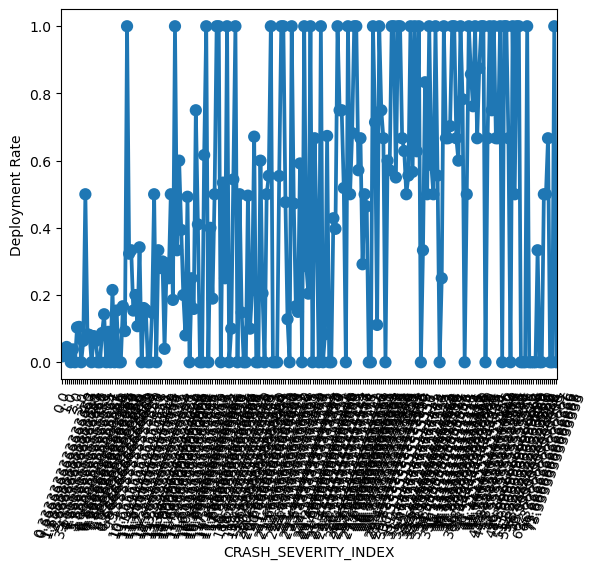

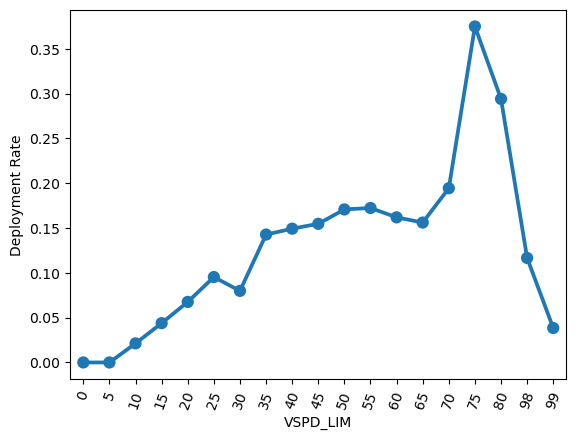

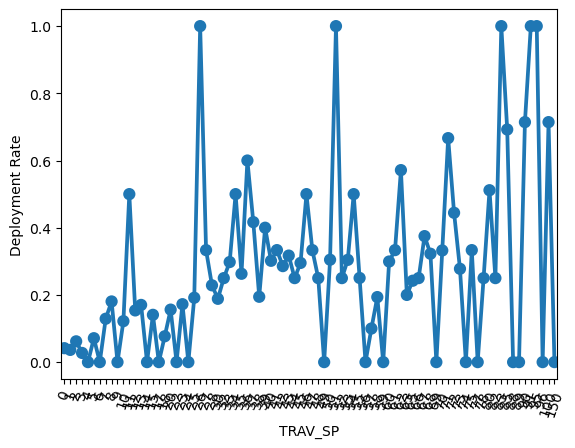

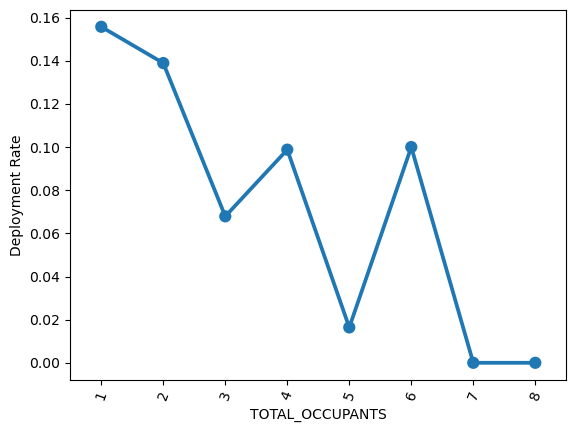

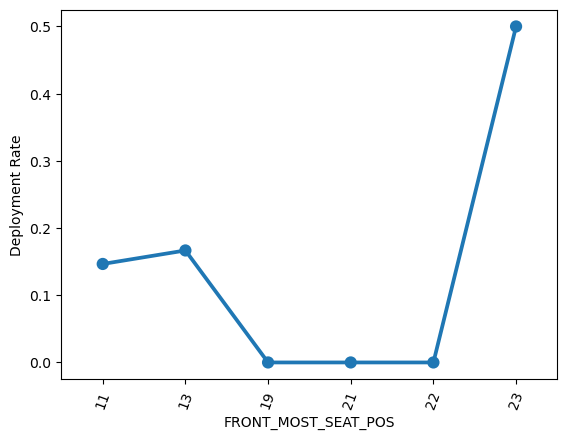

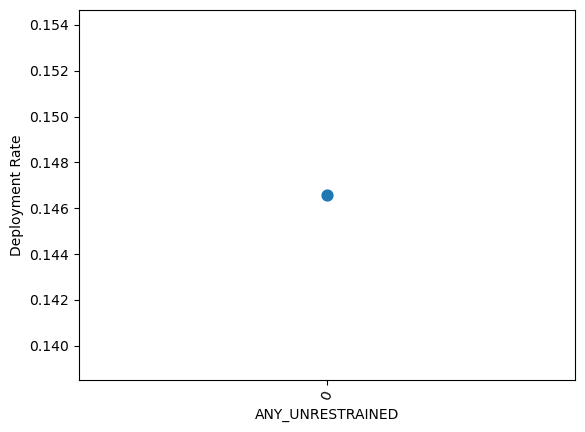

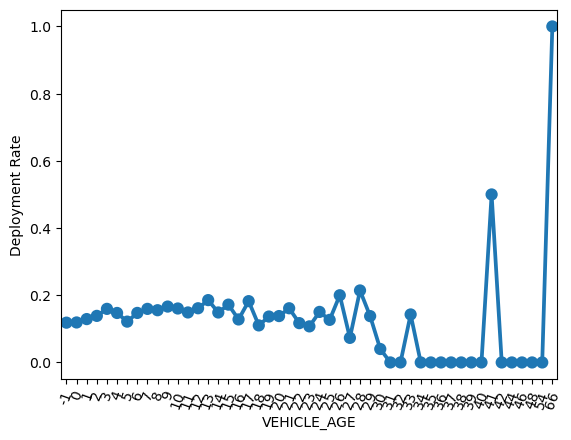

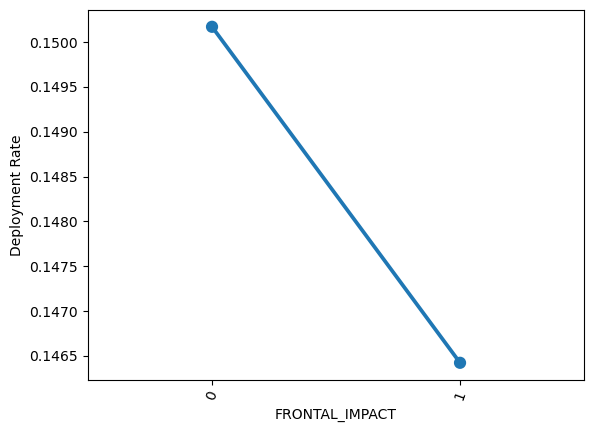

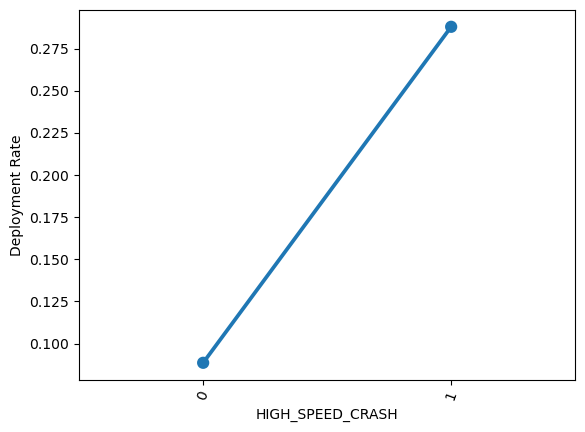

ValueError: cannot insert ALL_AIRBAGS_DEPLOYED, already exists

In [43]:
# interaction plots for num vars
for col in cols_: interaction_plot_cat(col, 70)

In [45]:
# encode MAX_INJURY_SEV for better graph and drop unknown variables
df['MAX_INJURY_SEV'] = df['MAX_INJURY_SEV'].replace({0:"No Injury", 1:"Possible Injury", 2:"Minor", 3: "Serious", 4:"Fatal"})
df = df[(df['MAX_INJURY_SEV'] != 5) & (df['MAX_INJURY_SEV'] != 9)]

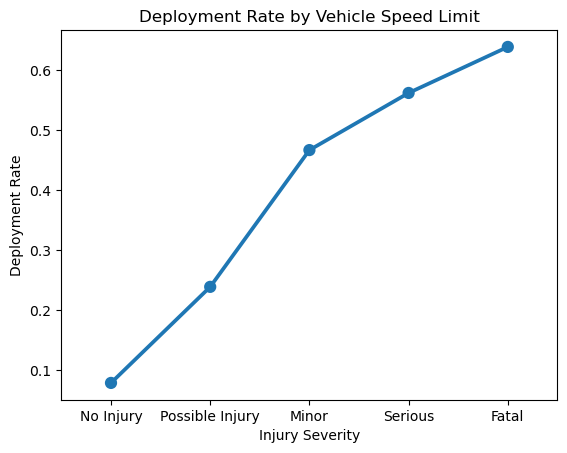

In [46]:
rates = df.groupby('MAX_INJURY_SEV')['ALL_AIRBAGS_DEPLOYED'].mean().reset_index()
rates = rates.sort_values('ALL_AIRBAGS_DEPLOYED')
sns.pointplot(data=rates, x='MAX_INJURY_SEV', y='ALL_AIRBAGS_DEPLOYED')
plt.xticks(rotation=0)
plt.title("Deployment Rate by Vehicle Speed Limit")
plt.xlabel("Injury Severity")
plt.ylabel("Deployment Rate")
plt.show()

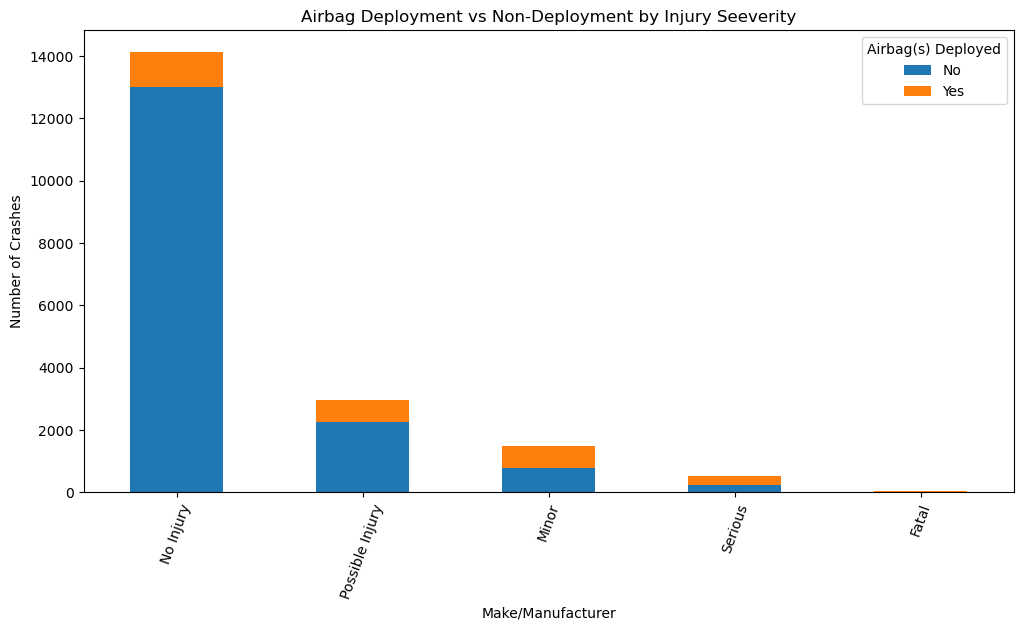

In [47]:
col = "MAX_INJURY_SEV"
summary = df.groupby([col, 'ALL_AIRBAGS_DEPLOYED']).size().reset_index(name='Count')

summary_pivot = summary.pivot(index=col, columns='ALL_AIRBAGS_DEPLOYED', values='Count')

summary_pivot = summary_pivot.loc[summary_pivot.sum(axis=1).sort_values(ascending=False).index]

summary_pivot.plot(kind='bar', stacked=True, figsize=(12,6))
# plt.title(f'Airbag Deployment vs Non-Deployment by {col}')
plt.title(f'Airbag Deployment vs Non-Deployment by Injury Seeverity')
plt.xlabel('Make/Manufacturer')
plt.ylabel('Number of Crashes')
plt.legend(labels=['No', 'Yes'], title='Airbag(s) Deployed')
plt.xticks(rotation=70)
plt.show()

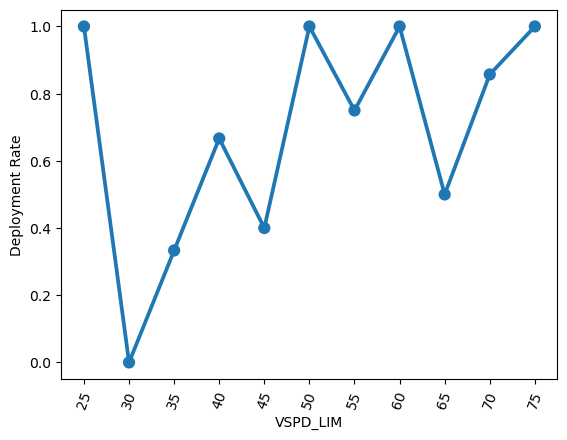

In [49]:
df_death = df[df['MAX_INJURY_SEV'] == "Fatal"]
rates = df_death.groupby('VSPD_LIM')['ALL_AIRBAGS_DEPLOYED'].mean().reset_index()
sns.pointplot(data=rates, x='VSPD_LIM', y='ALL_AIRBAGS_DEPLOYED')
plt.xticks(rotation=70)
plt.ylabel("Deployment Rate")
plt.show()


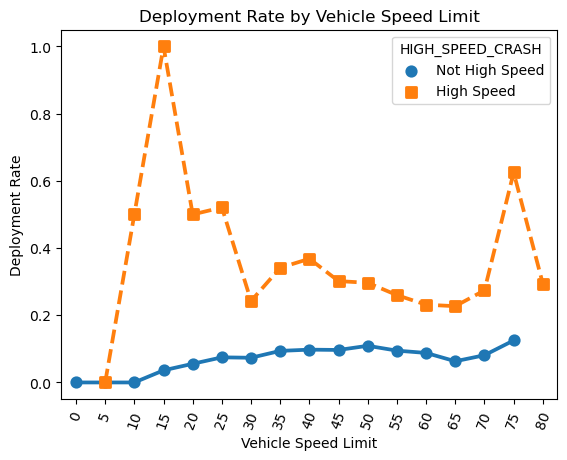

In [67]:
df = df[(df['VSPD_LIM'] != 98) & (df['VSPD_LIM'] != 99)]
df['HIGH_SPEED_CRASH'] = df['HIGH_SPEED_CRASH'].replace({0:"Not High Speed", 1:"High Speed"})
rates = df.groupby(['VSPD_LIM','HIGH_SPEED_CRASH'])['ALL_AIRBAGS_DEPLOYED'].mean().reset_index()
sns.pointplot(data=rates, x='VSPD_LIM', y='ALL_AIRBAGS_DEPLOYED', hue = 'HIGH_SPEED_CRASH',  markers=['o', 's'], 
              linestyles=['-', '--'])
plt.xticks(rotation=70)
plt.xlabel("Vehicle Speed Limit")
plt.ylabel("Deployment Rate")
plt.title("Deployment Rate by Vehicle Speed Limit")
plt.show()



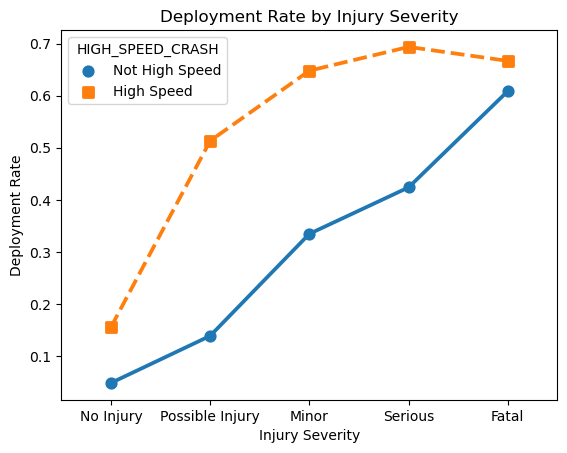

In [91]:
rates = df.groupby(['MAX_INJURY_SEV','HIGH_SPEED_CRASH'])['ALL_AIRBAGS_DEPLOYED'].mean().reset_index()
rates = rates.sort_values('ALL_AIRBAGS_DEPLOYED')
sns.pointplot(data=rates, x='MAX_INJURY_SEV', y='ALL_AIRBAGS_DEPLOYED', hue = 'HIGH_SPEED_CRASH',  markers=['o', 's'], 
              linestyles=['-', '--'])
plt.xticks(rotation=0)
plt.title("Deployment Rate by Injury Severity")
plt.xlabel("Injury Severity")
plt.ylabel("Deployment Rate")
plt.show()

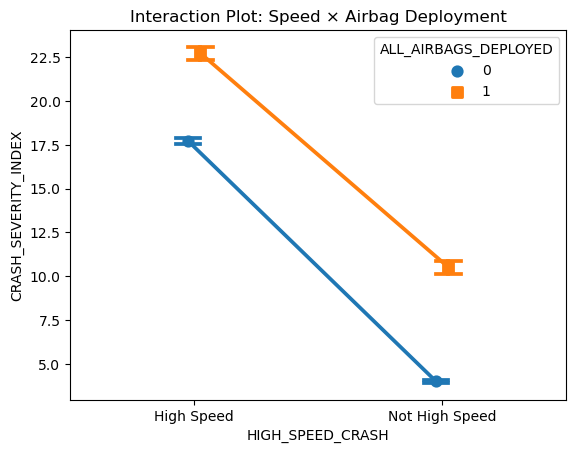

In [63]:
sns.pointplot(
    data=df,
    x="HIGH_SPEED_CRASH",
    y="CRASH_SEVERITY_INDEX",
    hue="ALL_AIRBAGS_DEPLOYED",
    dodge=True,
    markers=['o', 's'],
    capsize=0.1
)
plt.title("Interaction Plot: Speed × Airbag Deployment")
plt.show()

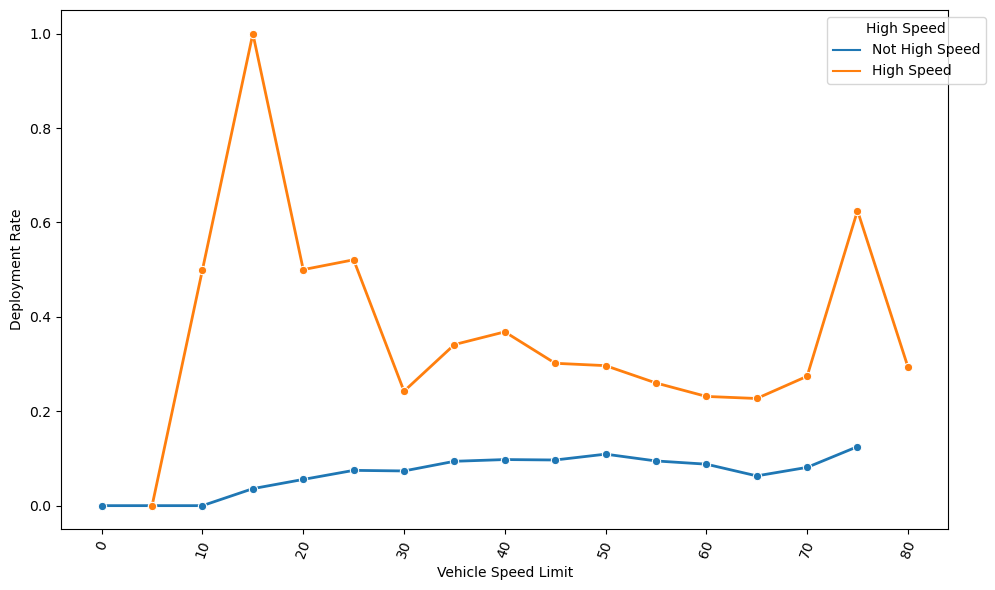

In [66]:
df = df[(df['VSPD_LIM'] != 98) & (df['VSPD_LIM'] != 99)]

rates = df.groupby(['VSPD_LIM', 'HIGH_SPEED_CRASH'])['ALL_AIRBAGS_DEPLOYED'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=rates, x='VSPD_LIM', y='ALL_AIRBAGS_DEPLOYED', 
             hue='HIGH_SPEED_CRASH', marker='o', linewidth=2)
plt.xticks(rotation=70)
plt.xlabel("Vehicle Speed Limit")
plt.ylabel("Deployment Rate")
plt.legend(title='High Speed', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

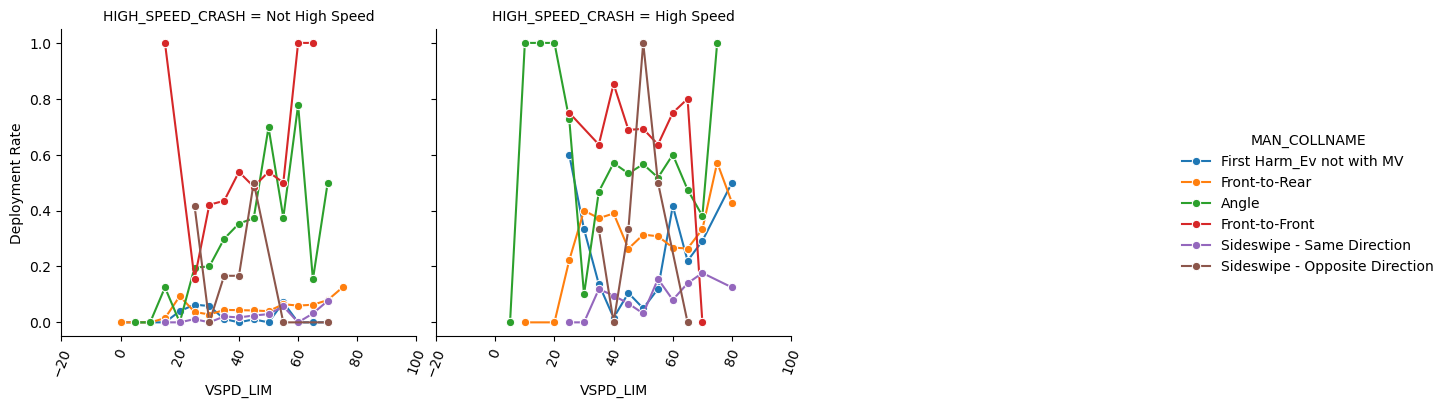

In [69]:
df = df[(df['VSPD_LIM'] != 98) & (df['VSPD_LIM'] != 99)]

rates = df.groupby(['VSPD_LIM', 'HIGH_SPEED_CRASH', 'MAN_COLLNAME'])['ALL_AIRBAGS_DEPLOYED'].mean().reset_index()

g = sns.FacetGrid(rates, col='HIGH_SPEED_CRASH', hue='MAN_COLLNAME', 
                  col_wrap=3, height=4, legend_out=True)
g.map(sns.lineplot, 'VSPD_LIM', 'ALL_AIRBAGS_DEPLOYED', marker='o')
g.add_legend()
g.set_xticklabels(rotation=70)
g.set_ylabels("Deployment Rate")
plt.show()

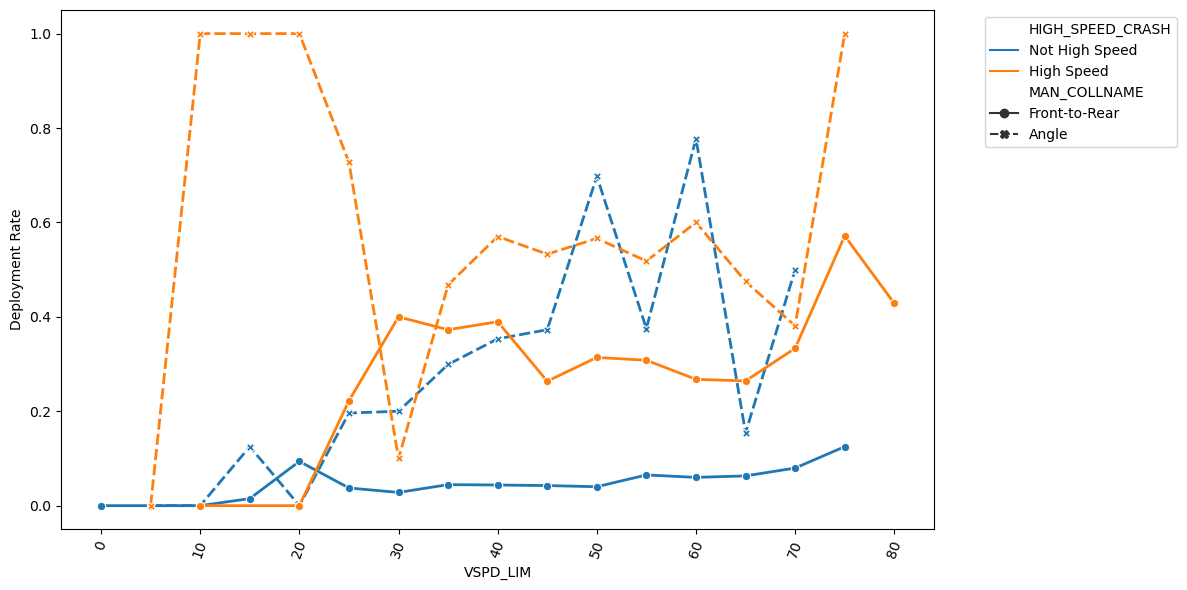

In [79]:
df = df[(df['VSPD_LIM'] != 98) & (df['VSPD_LIM'] != 99)]

rates = df.groupby(['VSPD_LIM', 'HIGH_SPEED_CRASH', 'MAN_COLLNAME'])['ALL_AIRBAGS_DEPLOYED'].mean().reset_index()
rates = rates[(rates['MAN_COLLNAME'] == "Front-to-Rear") | (rates['MAN_COLLNAME'] == "Angle")]

plt.figure(figsize=(12, 6))
sns.lineplot(data=rates, x='VSPD_LIM', y='ALL_AIRBAGS_DEPLOYED', 
             hue='HIGH_SPEED_CRASH',      # Different colors
             style='MAN_COLLNAME',    # Different line styles (solid, dashed, etc.)
             markers=True, 
             linewidth=2)
plt.xticks(rotation=70)
plt.ylabel("Deployment Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

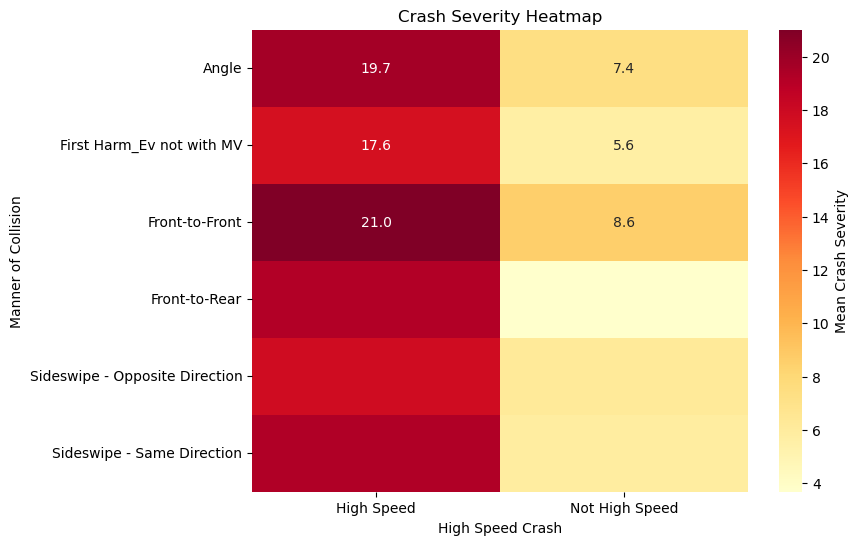

In [87]:
pivot_data = df.groupby(['MAN_COLLNAME', 'HIGH_SPEED_CRASH'])['CRASH_SEVERITY_INDEX'].mean().unstack()

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Mean Crash Severity'})
plt.xlabel('High Speed Crash')
plt.ylabel('Manner of Collision')
plt.title('Crash Severity Heatmap')
plt.show()

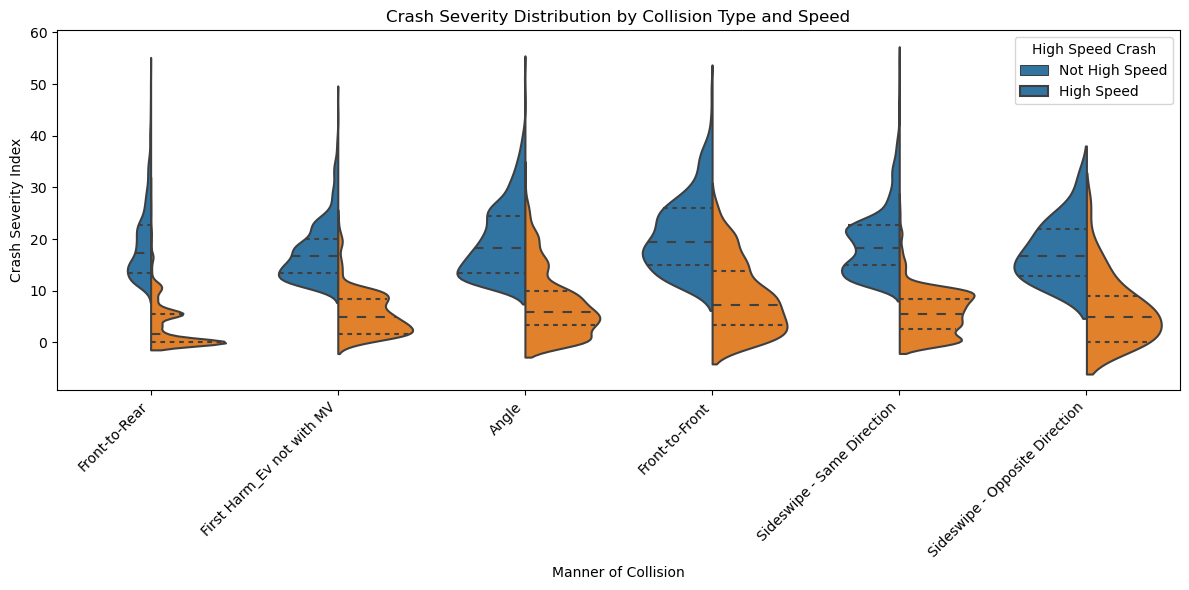

In [88]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='MAN_COLLNAME', y='CRASH_SEVERITY_INDEX', 
               hue='HIGH_SPEED_CRASH', split=True, inner='quartile')
plt.xlabel('Manner of Collision')
plt.ylabel('Crash Severity Index')
plt.title('Crash Severity Distribution by Collision Type and Speed')
plt.xticks(rotation=45, ha='right')
plt.legend(title='High Speed Crash', labels=['Not High Speed', 'High Speed'])
plt.tight_layout()
plt.show()

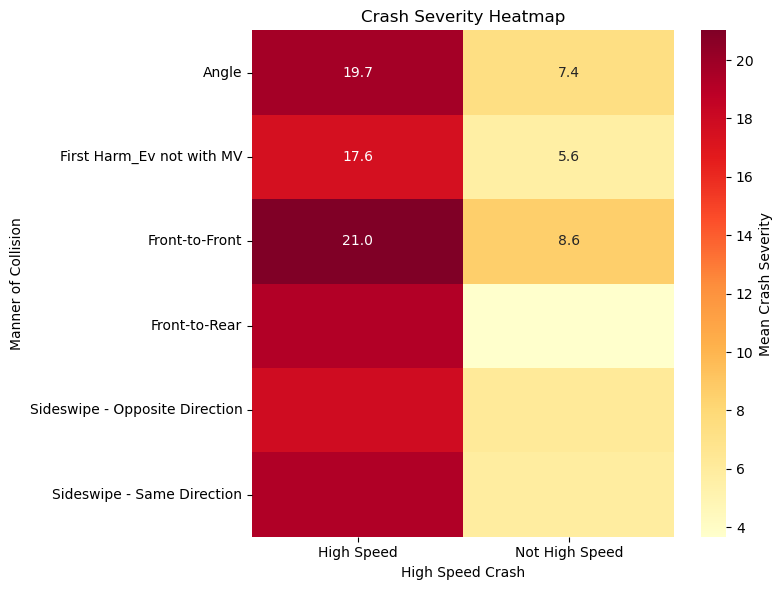

In [90]:
pivot_data = df.groupby(['MAN_COLLNAME', 'HIGH_SPEED_CRASH'])['CRASH_SEVERITY_INDEX'].mean().unstack()

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Mean Crash Severity'},
            annot_kws={'size': 10})  # Force annotations
plt.xlabel('High Speed Crash')
plt.ylabel('Manner of Collision')
plt.title('Crash Severity Heatmap')
plt.tight_layout()
plt.show()